In [4]:
# === FastRP-guided subgraph mining setup (use precomputed data) ===
import logging, sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
from scipy.io import loadmat

# configure paths
OUTDIR = Path("/projects/wangc/m344313/OVTMA_project/output/bms1_interface_radius_25_power")
graphs_path = OUTDIR / "graphs" / "G_all_radius.pkl"
graph_dict_pkl = OUTDIR / "graphs" / "graph_dict_radius.pkl"
embedding_path = OUTDIR / "evaluate" / "roi_supervised_best" / "roc_auc" / "roi_embedding.mat"
df_path = OUTDIR / "dataframes" / "df.csv"

# ---- columns in df.csv  ----
roi_col     = "roi_id"
subject_col = "patient_id"   # patient id
label_col   = "roi_label"    # 0/1
type_col    = "phenotype"    # cell type string
cell_col    = "cell_id"

# logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)
logging.info("Loading precomputed graph and embeddings...")

# load global graph (each ROI is an island)
with open(graphs_path, "rb") as f:
    G_all: nx.Graph = pickle.load(f)
logging.info(f"G_all loaded with {G_all.number_of_nodes()} nodes and {G_all.number_of_edges()} edges")

graph_dict = pickle.load(open(graph_dict_pkl, "rb"))
roi_list_all = list(graph_dict.keys())


# load metadata to attach ROI ↔ patient labels
df = pd.read_csv(df_path)
logging.info(f"df.csv loaded with shape {df.shape}")

# Align ROI and subject-level labels

roi_meta = (
    df[[roi_col, subject_col, label_col]]
    .dropna()
    .drop_duplicates(subset=[roi_col])
    .astype({label_col:int, roi_col:str, subject_col:str})
)
roi_to_y = dict(zip(roi_meta[roi_col], roi_meta[label_col]))
roi_to_group = dict(zip(roi_meta[roi_col], roi_meta[subject_col]))
roi_list = [r for r in roi_list_all if r in roi_to_y]
graphs   = [graph_dict[r] for r in roi_list]
y_roi    = np.array([roi_to_y[r] for r in roi_list], dtype=int)
groups   = np.array([roi_to_group[r] for r in roi_list], dtype=str)

logging.info(f"Usable ROIs: {len(roi_list)} | patients={len(np.unique(groups))} | class={{0:{(y_roi==0).sum()}, 1:{(y_roi==1).sum()}}}")



# Attach node 'label' (cell type) if available in df

if set([roi_col, cell_col, type_col]).issubset(df.columns):
    df_types = df[[roi_col, cell_col, type_col]].dropna()
    roi2type = {str(r): dict(zip(g[cell_col].astype(int), g[type_col].astype(str))) for r, g in df_types.groupby(roi_col)}
    for roi, G in zip(roi_list, graphs):
        mapping = roi2type.get(str(roi), {})
        nx.set_node_attributes(G, {n: mapping.get(int(n), "UNK") for n in G.nodes()}, name="label")
else:
    for G in graphs:
        nx.set_node_attributes(G, {n: "UNK" for n in G.nodes()}, name="label")


2025-11-19 12:36:22,847 | INFO | Loading precomputed graph and embeddings...
2025-11-19 12:36:26,101 | INFO | G_all loaded with 1148907 nodes and 1369198 edges
2025-11-19 12:36:28,775 | INFO | df.csv loaded with shape (1148907, 8)
2025-11-19 12:36:28,869 | INFO | Usable ROIs: 219 | patients=21 | class={0:139, 1:80}


In [5]:
sys.path.append('..')
import yaml
from src.node_embeddings import node_embedding
from src.utils import align_df_with_G_all
df_aligned = align_df_with_G_all(df, G_all)
with open(OUTDIR / "evaluate" / "roi_supervised_best" / "roc_auc" / "best_roi_supervision.yaml", "r") as f:
    best_hyper_params = yaml.safe_load(f)["best_hyper_params"]
Z_nodes = node_embedding(G_all, df_aligned, best_hyper_params)

/people/m344313/TMA_Graph_Embedding/notebooks/../src/fastrp.py:23: RuntimeWarning: divide by zero encountered in divide
  normalizer = spdiags(np.squeeze(1.0 / csc_matrix.sum(A, axis=1) ), 0, N, N)


In [39]:
phenos = pd.get_dummies(df_aligned["phenotype"],  dtype=float)
phenos.columns

Index(['B Cell', 'Cytotoxic T Cell', 'Dendritic Cell', 'Helper T Cell',
       'Macrophage', 'Monocyte', 'Neutrophil', 'Regulatory T Cell',
       'Stromal Cell', 'Tumor Cell', 'Unclassified Immune', 'Vasculature'],
      dtype='object')

In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def fps_indices(X, m):
    """Farthest Point Sampling on rows of X; returns selected row indices."""
    if X.shape[0] == 0:
        return np.array([], dtype=int)
    sel = [int(np.random.randint(0, X.shape[0]))]
    dist = np.full(X.shape[0], np.inf)
    for _ in range(1, min(m, X.shape[0])):
        d = np.linalg.norm(X - X[sel[-1]], axis=1)
        dist = np.minimum(dist, d)
        sel.append(int(np.argmax(dist)))
    return np.array(sel, dtype=int)

Z = Z_nodes
# Build global node index ↔ (roi, local_node) mapping
global_index = []
roi_offsets = {}
start = 0
for ridx, (roi, G) in enumerate(zip(roi_list, graphs)):
    n = G.number_of_nodes()
    roi_offsets[roi] = (start, start + n)
    for n_id in G.nodes():
        global_index.append((ridx, roi, int(n_id)))
    start += n

node_df = pd.DataFrame(global_index, columns=["roi_idx", "roi", "cell_id"])


# Assume order of nodes in G_all matches global_index constructed from connected components.
# If node ordering differs, you may need to align using the original tuple labels.
Z_nodes = Z.astype(np.float32)
# Weak labels at node level = ROI label
y_node = node_df["roi"].map(roi_to_y).astype(int).values
# Train a linear classifier to get node-level saliency
clf_node = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000, class_weight="balanced")
)
clf_node.fit(Z_nodes, y_node)
p_node = clf_node.predict_proba(Z_nodes)[:, 1]
saliency = np.abs(p_node - 0.5)
node_df["saliency"] = saliency
node_df["p_node"]   = p_node


In [8]:
from sklearn.model_selection import StratifiedGroupKFold
from collections import Counter, defaultdict
import hashlib

# --- 3) Saliency threshold + FPS anchors (stratified by class, capped per ROI and per group) ---
perc = 99               # saliency percentile cutoff
per_roi_cap = 30        # max anchors per ROI
per_group_total = 500   # max anchors per class across all ROIs
ego_hops = 3
max_nodes_per_ego = 40

anchors = []
for grp in [0, 1]:
    cand = node_df[(node_df["saliency"] >= np.percentile(node_df["saliency"], perc)) &
                   (node_df["roi"].map(roi_to_y).values == grp)]
    chosen = []
    for roi, sub in cand.groupby("roi"):
        idx = sub.index.values
        if idx.size == 0:
            continue
        Xr = Z_nodes[idx]
        m  = min(len(idx), per_roi_cap)
        keep_local = idx[fps_indices(Xr, m=m)]
        chosen.extend(keep_local.tolist())
    # Global cap with FPS over pooled anchors
    if len(chosen) > per_group_total:
        Xc = Z_nodes[chosen]
        keep = fps_indices(Xc, m=per_group_total)
        chosen = [chosen[i] for i in keep.tolist()]
    anchors.extend(chosen)

anchors = np.array(sorted(set(anchors)), dtype=int)
logging.info(f"Selected anchors: total={len(anchors)} (grp0={int((node_df.loc[anchors,'roi'].map(roi_to_y).values==0).sum())}, grp1={int((node_df.loc[anchors,'roi'].map(roi_to_y).values==1).sum())})")

# --- 4) Ego-subgraph extraction + motif hashing (structure + multiset of node colors) ---
def _adj_signature(G, nodes):
    idx = {n:i for i,n in enumerate(nodes)}
    bits = []
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            bits.append('1' if G.has_edge(nodes[i], nodes[j]) else '0')
    return ''.join(bits)

def _color_multiset(G, nodes, attr="label"):
    return tuple(sorted([str(G.nodes[n].get(attr, "UNK")) for n in nodes]))

def motif_hash(G, nodes, attr="label"):
    k = len(nodes); adj = _adj_signature(G, nodes); cols = _color_multiset(G, nodes, attr=attr)
    payload = f"{k}|{adj}|{','.join(cols)}"
    return hashlib.sha1(payload.encode()).hexdigest(), (k, adj, cols)

roi_to_counts = defaultdict(Counter)
vocab = set()

# Helper: quickly get the local node list per ROI in stable order
roi_nodes_list = {roi: list(G.nodes()) for roi, G in zip(roi_list, graphs)}

for idx in anchors:
    ridx = int(node_df.iloc[idx]["roi_idx"])
    roi  = roi_list[ridx]
    G    = graphs[ridx]
    anchor_local = int(node_df.iloc[idx]["cell_id"])
    nodes = list(nx.ego_graph(G, anchor_local, radius=ego_hops).nodes())
    # trim oversized egos by nearest in embedding space (use Z_nodes if node-level, else structural X)
    if len(nodes) > max_nodes_per_ego:
        # Build indices into node_df for these local nodes
        start, end = roi_offsets[roi]
        local_to_global = {n: start + roi_nodes_list[roi].index(n) for n in roi_nodes_list[roi]}
        gidx = np.array([local_to_global[n] for n in nodes], dtype=int)
        center_idx = start + roi_nodes_list[roi].index(anchor_local)
        d = np.linalg.norm(Z_nodes[gidx] - Z_nodes[center_idx], axis=1)
        keep = np.argsort(d)[:max_nodes_per_ego]
        nodes = [nodes[i] for i in keep]
    h, meta = motif_hash(G, nodes, attr="label")
    roi_to_counts[roi][h] += 1
    vocab.add(h)

vocab = sorted(vocab)
tok2idx = {t:i for i,t in enumerate(vocab)}
logging.info(f"Sampled motifs: {len(vocab)} unique")


2025-11-19 12:44:17,893 | INFO | Selected anchors: total=1000 (grp0=500, grp1=500)
2025-11-19 12:44:20,849 | INFO | Sampled motifs: 1000 unique


In [71]:
'''save node_df with anchors column and x,y coordinates''' 

# make sure cell_id types match
node_df["cell_id"] = node_df["cell_id"].astype(int)
df_aligned["cell_id"] = df_aligned["cell_id"].astype(int)

# pull x, y from df_aligned and merge into node_df
coords = df_aligned[["roi_id", "cell_id", "x", "y"]].copy()
coords["roi_id"] = coords["roi_id"].astype(str)
node_df["roi"]   = node_df["roi"].astype(str)

node_df = (
    node_df
    .merge(coords, left_on=["roi", "cell_id"],
           right_on=["roi_id", "cell_id"],
           how="left")
    .drop(columns=["roi_id"])
)

# mark anchors
node_df["anchor"] = False
node_df.loc[anchors, "anchor"] = True


node_df.to_csv('/projects/wangc/m344313/OVTMA_project/output/node_df_with_anchors.csv', index=False)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 81000 samples in 0.004s...
[t-SNE] Computed neighbors for 81000 samples in 3.742s...
[t-SNE] Computed conditional probabilities for sample 1000 / 81000
[t-SNE] Computed conditional probabilities for sample 2000 / 81000
[t-SNE] Computed conditional probabilities for sample 3000 / 81000
[t-SNE] Computed conditional probabilities for sample 4000 / 81000
[t-SNE] Computed conditional probabilities for sample 5000 / 81000
[t-SNE] Computed conditional probabilities for sample 6000 / 81000
[t-SNE] Computed conditional probabilities for sample 7000 / 81000
[t-SNE] Computed conditional probabilities for sample 8000 / 81000
[t-SNE] Computed conditional probabilities for sample 9000 / 81000
[t-SNE] Computed conditional probabilities for sample 10000 / 81000
[t-SNE] Computed conditional probabilities for sample 11000 / 81000
[t-SNE] Computed conditional probabilities for sample 12000 / 81000
[t-SNE] Computed conditional probabilities for sam

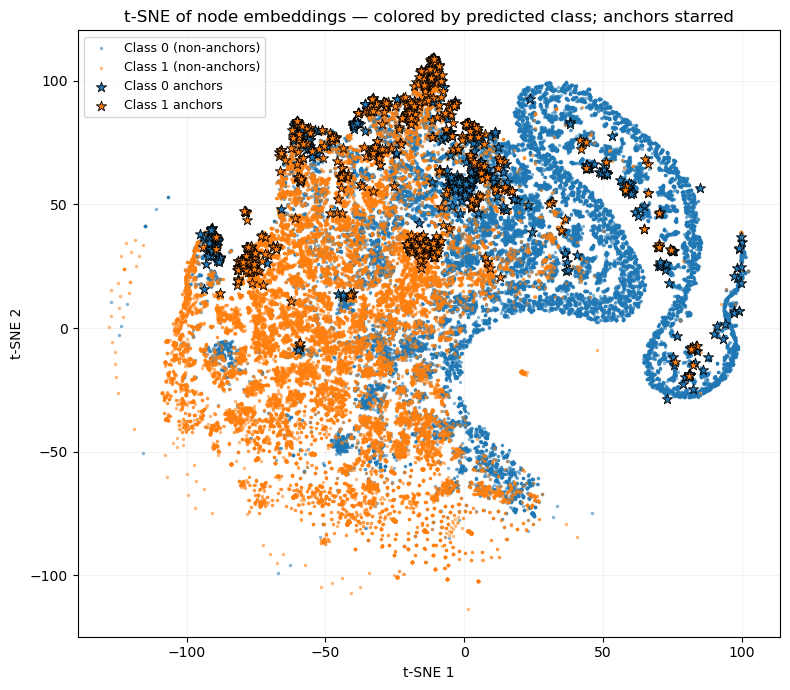

In [7]:
''' tSNE for the embeddings (cell type and anchors)'''
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- 1) Predicted class from your trained node-level classifier ---
# p_node already computed; threshold at 0.5
y_pred_node = (p_node >= 0.5).astype(int)

# --- 2) Optional subsampling to speed up t-SNE ---
# Keep all anchors; randomly sample up to N other points
N_MAX_NON_ANCHORS = 80000  # adjust based on memory/size; set None to disable
all_idx = np.arange(Z_nodes.shape[0])
anchor_mask = np.zeros(Z_nodes.shape[0], dtype=bool)
anchor_mask[anchors] = True

non_anchor_idx = all_idx[~anchor_mask]
if (N_MAX_NON_ANCHORS is not None) and (non_anchor_idx.size > N_MAX_NON_ANCHORS):
    rng = np.random.default_rng(42)
    keep_non = rng.choice(non_anchor_idx, size=N_MAX_NON_ANCHORS, replace=False)
    plot_idx = np.concatenate([anchors, keep_non])
else:
    plot_idx = all_idx

# --- 3) Run t-SNE on the selected subset ---
X = Z_nodes[plot_idx]
y_plot = y_pred_node[plot_idx]
is_anchor_plot = anchor_mask[plot_idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    early_exaggeration=12.0,
    learning_rate="auto",
    init="pca",
    metric="euclidean",
    random_state=42,
    verbose=1,
)
X2 = tsne.fit_transform(X)

# --- 4) Plot: color by predicted class, mark anchors with star ---
palette = plt.cm.tab10.colors
colors = {0: palette[0], 1: palette[1]}  # 0=blue, 1=orange

fig, ax = plt.subplots(figsize=(8, 7))

# base scatter (non-anchors)
base = (~is_anchor_plot)
for cls in (0, 1):
    m = base & (y_plot == cls)
    if np.any(m):
        ax.scatter(
            X2[m, 0], X2[m, 1],
            s=6, alpha=0.55, linewidths=0,
            c=[colors[cls]], label=f"Class {cls} (non-anchors)"
        )

# anchors on top (stars, black edge)
for cls in (0, 1):
    m = is_anchor_plot & (y_plot == cls)
    if np.any(m):
        ax.scatter(
            X2[m, 0], X2[m, 1],
            s=60, marker="*", linewidths=0.6, edgecolors="k",
            c=[colors[cls]], label=f"Class {cls} anchors"
        )

ax.set_title("t-SNE of node embeddings — colored by predicted class; anchors starred")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
# merge duplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="best", frameon=True, fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()


## Embedding PCA analysis

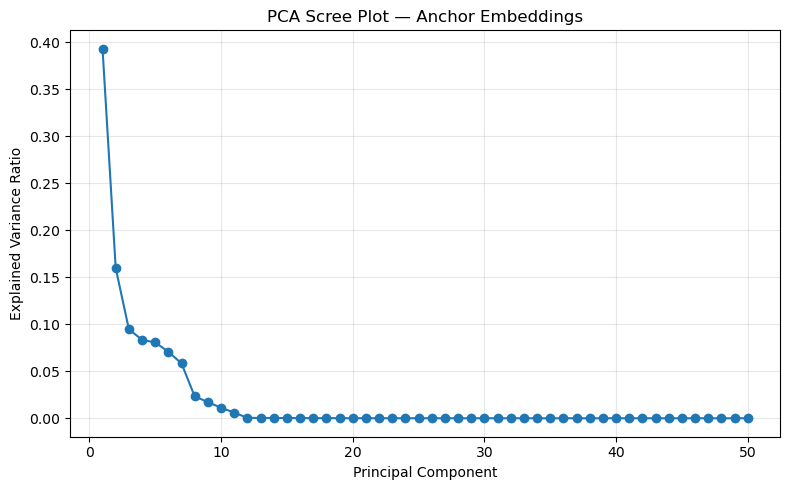

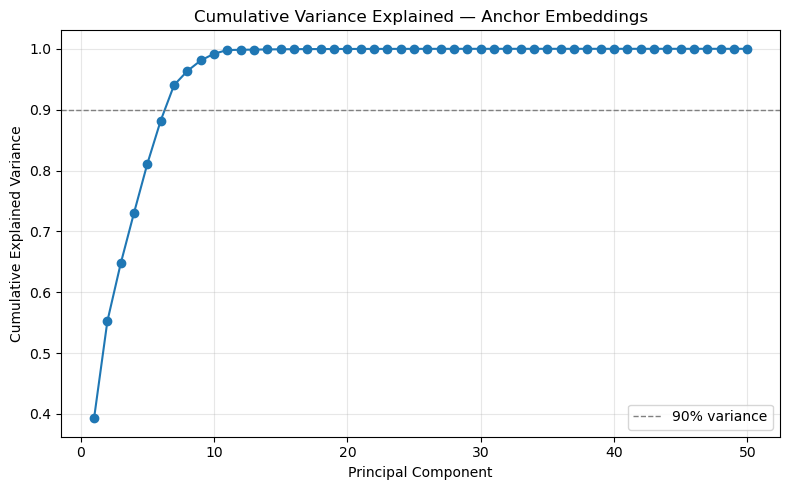

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
X_anchor = Z_nodes[anchors]
# --- Run PCA on anchor embeddings ---
pca = PCA(n_components=min(50, X_anchor.shape[1]))  # limit to 50 PCs or feature dim
pca.fit(X_anchor)

expl_var = pca.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

# --- Scree plot (explained variance per PC) ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(1, len(expl_var) + 1),
    expl_var,
    marker="o",
    linewidth=1.5
)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Scree Plot — Anchor Embeddings")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Cumulative variance plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(1, len(cum_var) + 1),
    cum_var,
    marker="o",
    linewidth=1.5
)
ax.axhline(0.9, linestyle="--", color="gray", linewidth=1, label="90% variance")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("Cumulative Variance Explained — Anchor Embeddings")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


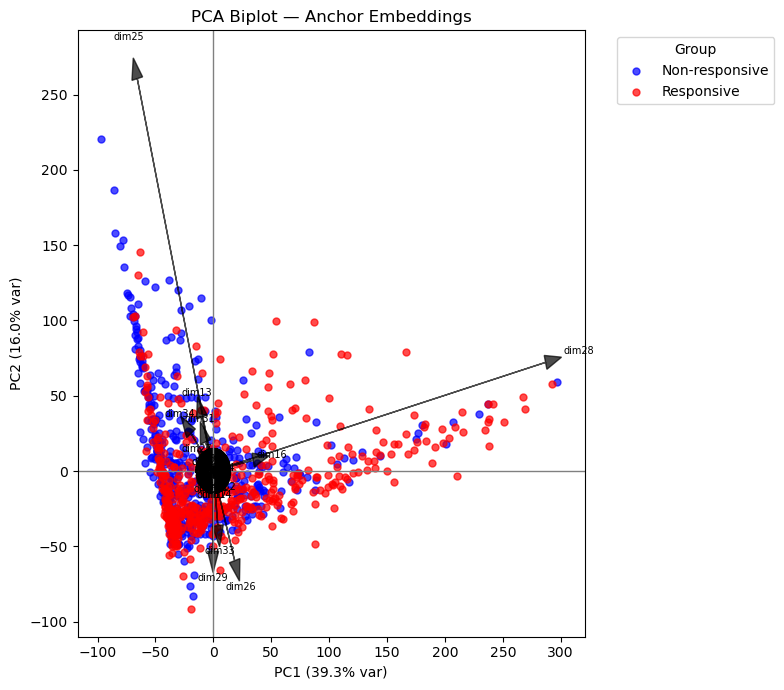

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

# ---------------------------------------------------
# Choose coloring scheme:
y_node_anchor = node_df.loc[anchors, "roi"].map(roi_to_y).astype(int).values
roi_ids_anchor = df_aligned.loc[anchors, "roi_id"].to_numpy()
patient_ids_anchor = df_aligned.loc[anchors, "patient_id"].to_numpy()
# color_labels = roi_ids_anchor       # color by ROI
color_labels = y_node_anchor     # color by patient
# ---------------------------------------------------

# PCs (scores)
scores = pca.transform(X_anchor)[:, :2]   # first 2 PCs
pc1, pc2 = scores[:, 0], scores[:, 1]

# Feature loadings (first 2 PCs)
loadings = pca.components_[:2].T   # shape: (num_features, 2)

# Normalize loadings for nicer arrows
loading_scale = 0.8 * max(pc1.max() - pc1.min(), pc2.max() - pc2.min())
loadings_scaled = loadings * loading_scale

# Unique groups and colors
unique_groups = np.unique(color_labels)

# discrete color map
group_colors = {
    0: "blue",
    1: "red",
}

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))

# Scatter points (scores)
for g in unique_groups:
    text = 'Non-responsive' if g == 0 else 'Responsive'
    m = (color_labels == g)
    ax.scatter(
        scores[m, 0],
        scores[m, 1],
        s=25,
        alpha=0.7,
        color=group_colors[g],
        label=text,
    )

# Loading arrows
for i in range(loadings.shape[0]):
    ax.arrow(
        0, 0,
        loadings_scaled[i, 0],
        loadings_scaled[i, 1],
        color="black",
        width=0.002,
        head_width=0.03 * loading_scale,
        alpha=0.7,
        length_includes_head=True,
    )
    ax.text(
        loadings_scaled[i, 0] * 1.05,
        loadings_scaled[i, 1] * 1.05,
        f"dim{i+1}",
        fontsize=7,
        ha="center",
        va="center",
    )

ax.set_xlabel(f"PC1 ({expl_var[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({expl_var[1]*100:.1f}% var)")
ax.set_title("PCA Biplot — Anchor Embeddings")

ax.axhline(0, color='grey', linewidth=1)
ax.axvline(0, color='grey', linewidth=1)

ax.legend(title="Group", bbox_to_anchor=(1.05, 1.0), loc="upper left")

fig.tight_layout()
plt.show()


cell type orders Index(['B Cell', 'Cytotoxic T Cell', 'Dendritic Cell', 'Helper T Cell',
       'Macrophage', 'Monocyte', 'Neutrophil', 'Regulatory T Cell',
       'Stromal Cell', 'Tumor Cell', 'Unclassified Immune', 'Vasculature'],
      dtype='object')


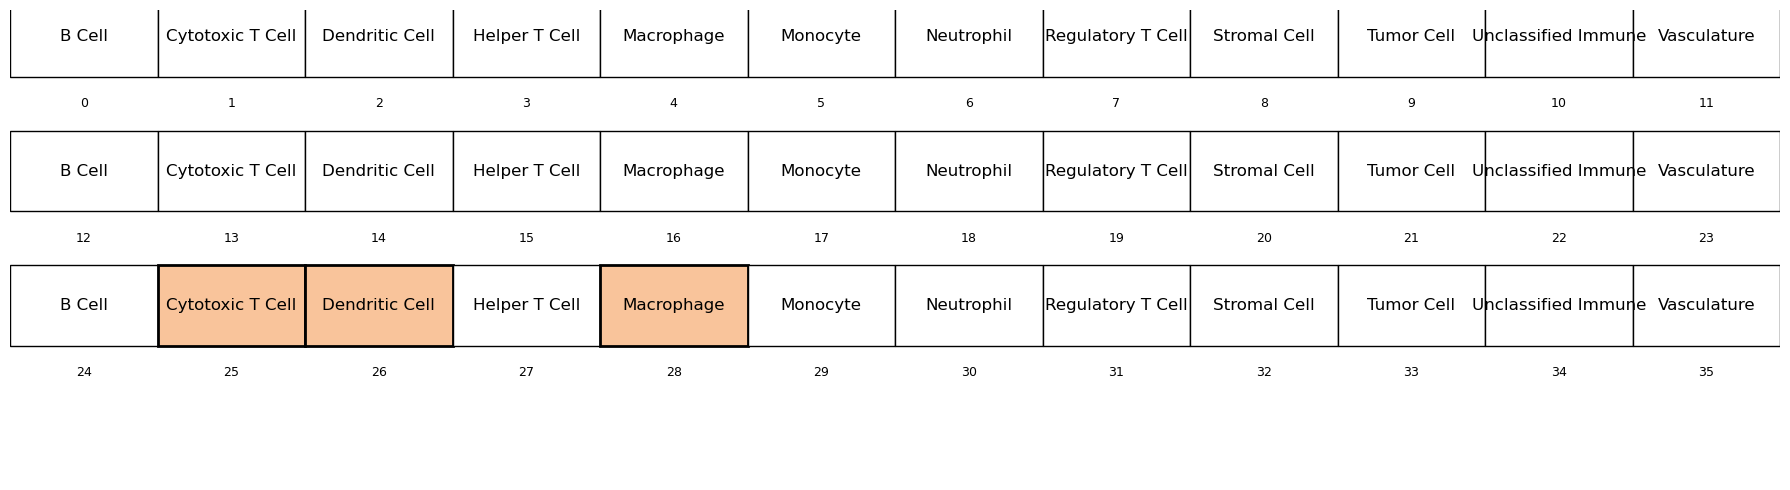

In [62]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
print(f'cell type orders {pd.get_dummies(df_aligned["phenotype"]).columns}')
# --- cell types repeated 3× ---
cell_types = [
    'B Cell', 'Cytotoxic T Cell', 'Dendritic Cell', 'Helper T Cell',
    'Macrophage', 'Monocyte', 'Neutrophil', 'Regulatory T Cell',
    'Stromal Cell', 'Tumor Cell', 'Unclassified Immune', 'Vasculature'
]

seq = cell_types * 3  # 36 items
N = len(seq)

# --- parameters ---
n_rows = 3
n_cols = len(cell_types)
box_w = 1.0
box_h = 0.6

highlight_indices = {25, 26, 28}
highlight_color = "#f9c49b"   # light orange

# --- figure ---
fig, ax = plt.subplots(figsize=(18, 5))

# Turn off axes
ax.set_xlim(0, n_cols)
ax.set_ylim(-n_rows, 0.5)
ax.axis("off")

for idx, text in enumerate(seq):
    row = idx // n_cols   # 0,1,2
    col = idx % n_cols

    # y-coordinate for the row (top row = y=0)
    y = -row

    # highlight if needed
    if idx in highlight_indices:
        facecolor = highlight_color
        edgecolor = "black"
        lw = 2
    else:
        facecolor = "white"
        edgecolor = "black"
        lw = 1

    # Draw box
    rect = Rectangle((col, y), box_w, box_h,
                     facecolor=facecolor, edgecolor=edgecolor, linewidth=lw)
    ax.add_patch(rect)

    # Add text (centered)
    ax.text(col + box_w/2, y + box_h/2, text,
            ha='center', va='center', fontsize=12)

    # Add index label under the box
    ax.text(col + box_w/2, y - 0.15, str(idx),
            ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()


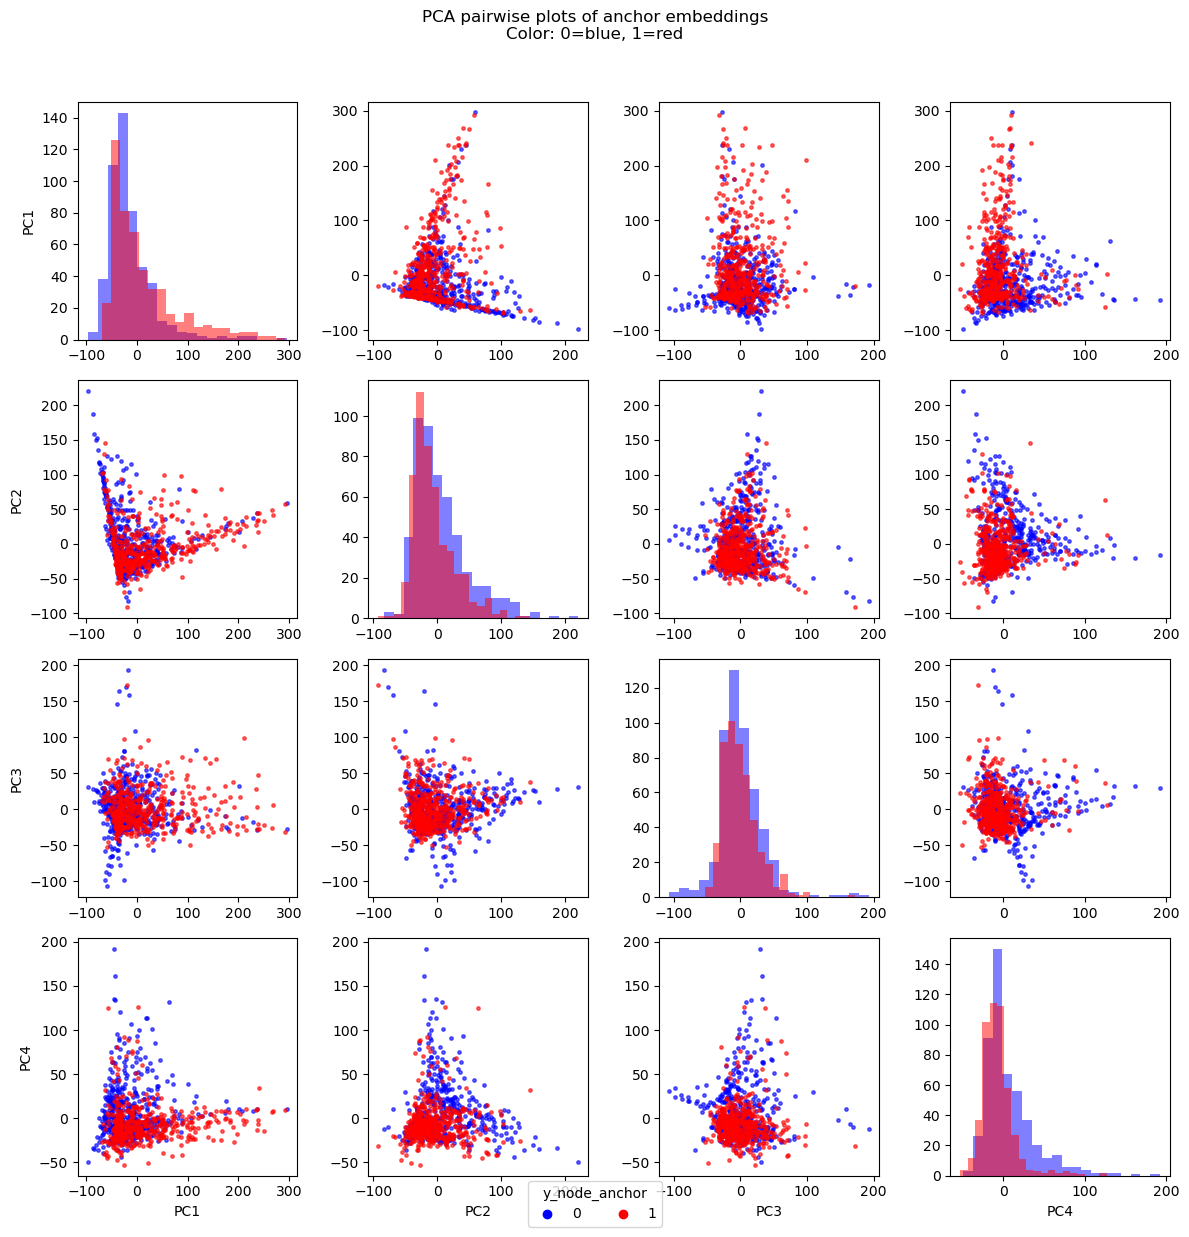

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ---- 1) PCA on anchor embeddings (first 4 PCs) ----
pca4 = PCA(n_components=4)
scores4 = pca4.fit_transform(X_anchor)  # shape: (n_anchors, 4)

pc_labels = [f"PC{i}" for i in range(1, 5)]

df_pcs = pd.DataFrame(scores4, columns=pc_labels)
df_pcs["y"] = y_node_anchor.astype(int)   # ensure 0/1 integer

# ---- 2) Discrete colormap: 0 → blue, 1 → red ----
y_colors = {0: "blue", 1: "red"}

# ---- 3) 4×4 grid (rows = PC on y-axis, cols = PC on x-axis) ----
fig, axes = plt.subplots(4, 4, figsize=(12, 12), sharex=False, sharey=False)

for i, row_pc in enumerate(pc_labels):
    for j, col_pc in enumerate(pc_labels):
        ax = axes[i, j]

        if i == j:
            # Diagonal: 1D histogram per class
            for yy in [0, 1]:
                m = df_pcs["y"] == yy
                ax.hist(
                    df_pcs.loc[m, row_pc],
                    bins=20,
                    alpha=0.5,
                    color=y_colors[yy],
                )
        else:
            # Off-diagonal: scatter
            for yy in [0, 1]:
                m = df_pcs["y"] == yy
                ax.scatter(
                    df_pcs.loc[m, col_pc],
                    df_pcs.loc[m, row_pc],
                    s=6,
                    alpha=0.6,
                    color=y_colors[yy],
                )

        # label edges only
        if i == 3:
            ax.set_xlabel(col_pc)
        else:
            ax.set_xlabel("")
        if j == 0:
            ax.set_ylabel(row_pc)
        else:
            ax.set_ylabel("")

# ---- 4) Legend ----
handles = [
    plt.Line2D([], [], marker="o", linestyle="None", color="blue", markersize=6),
    plt.Line2D([], [], marker="o", linestyle="None", color="red", markersize=6),
]
labels = ["0", "1"]

fig.legend(
    handles,
    labels,
    title="y_node_anchor",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=2,
)

fig.suptitle("PCA pairwise plots of anchor embeddings\nColor: 0=blue, 1=red", y=1.02)
fig.tight_layout()
plt.show()


## Plot embedding colored with different hand crafted features(trying to explain)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.080s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 23.277143
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.004379
[t-SNE] KL divergence after 1000 iterations: 0.988391


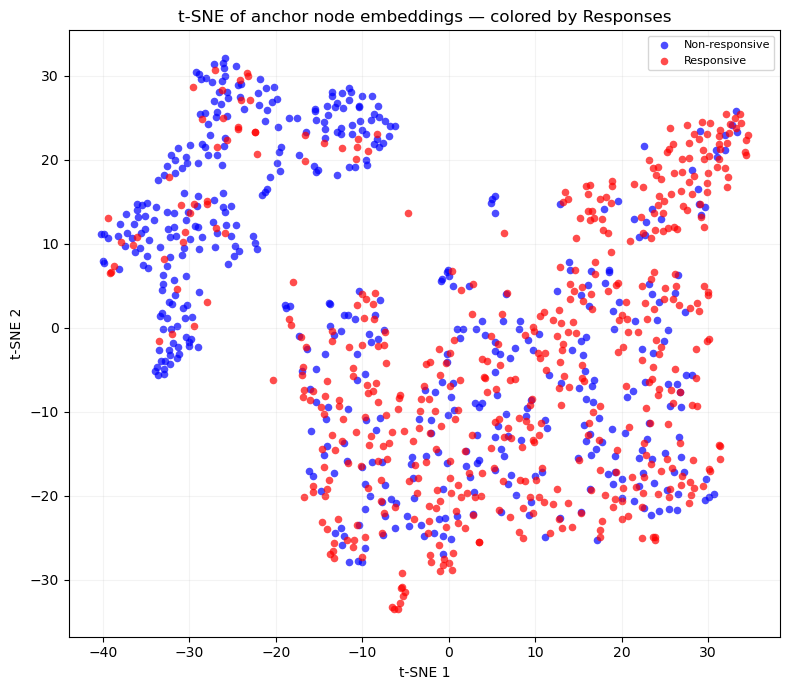

/tmp/ipykernel_3631594/314270452.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_patients))  # up to 20 distinct colors nicely


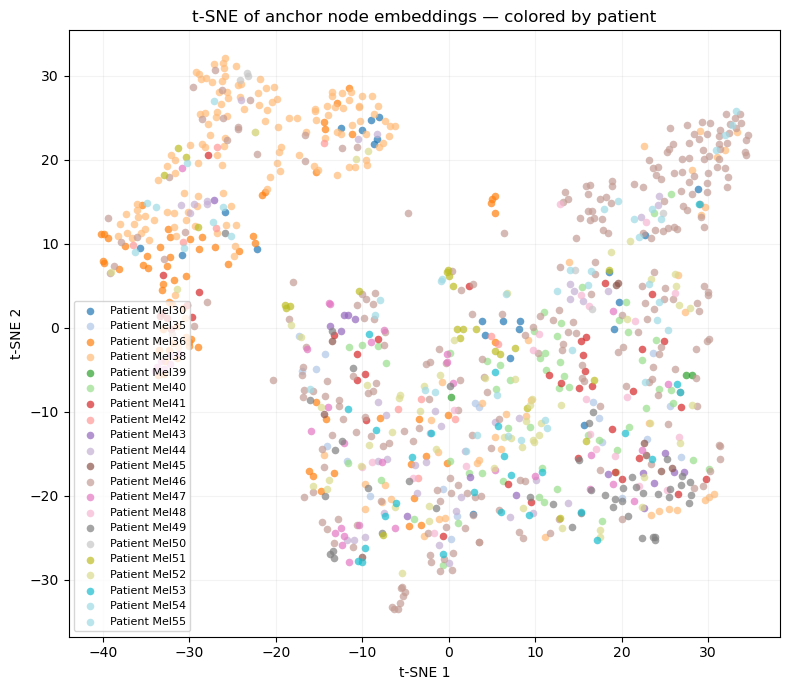

/tmp/ipykernel_3631594/314270452.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_cell_types))  # up to 20 distinct colors nicely


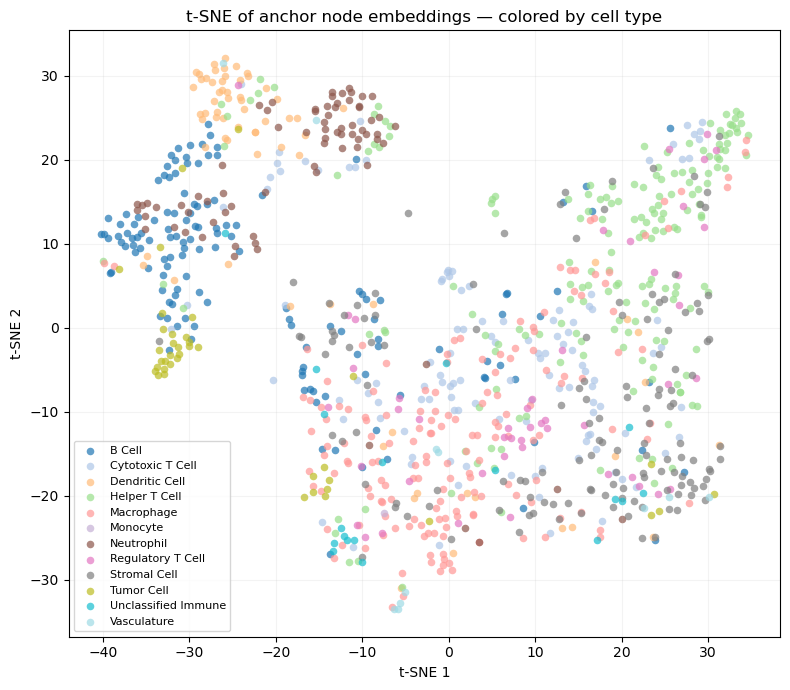

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- t-SNE on anchors only, colored by roi_id ---

# 1) Anchor embeddings
X_anchor = Z_nodes[anchors]

# 2) Get roi_id for each anchor (assuming df_aligned is aligned with node indices)
# If df_aligned index matches node indices:
y_node_anchor = node_df.loc[anchors, "roi"].map(roi_to_y).astype(int).values
roi_ids_anchor = df_aligned.loc[anchors, "roi_id"].to_numpy()
patient_ids_anchor = df_aligned.loc[anchors, "patient_id"].to_numpy()

# 3) Run t-SNE
tsne_anchor = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(anchors) // 3)),  # auto-adjust a bit if anchors are few
    early_exaggeration=12.0,
    learning_rate="auto",
    init="pca",
    metric="euclidean",
    random_state=42,
    verbose=1,
)
X2_anchor = tsne_anchor.fit_transform(X_anchor)

# 4) Plot: color by roi_id
unique_y = np.unique(y_node_anchor)
group_colors = {
    0: "blue",
    1: "red",
}


fig, ax = plt.subplots(figsize=(8, 7))

for i, y in enumerate(unique_y):
    m = (y_node_anchor == y)
    text = 'Non-responsive' if y == 0 else 'Responsive'
    ax.scatter(
        X2_anchor[m, 0],
        X2_anchor[m, 1],
        s=30,
        alpha=0.7,
        linewidths=0,
        c=[group_colors[y]],
        label=text,
    )

ax.set_title("t-SNE of anchor node embeddings — colored by Responses")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="best", fontsize=8, frameon=True)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

'''tSNE Color by Patient'''
unique_patients = np.unique(patient_ids_anchor)
cmap = plt.cm.get_cmap("tab20", len(unique_patients))  # up to 20 distinct colors nicely

fig, ax = plt.subplots(figsize=(8, 7))

for i, patient in enumerate(unique_patients):
    m = (patient_ids_anchor == patient)
    ax.scatter(
        X2_anchor[m, 0],
        X2_anchor[m, 1],
        s=30,
        alpha=0.7,
        linewidths=0,
        c=[cmap(i)],
        label=f"Patient {patient}",
    )

ax.set_title("t-SNE of anchor node embeddings — colored by patient")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="best", fontsize=8, frameon=True)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

cell_type_anchor = df_aligned.loc[anchors, "phenotype"].to_numpy()

unique_cell_types = np.unique(cell_type_anchor)
cmap = plt.cm.get_cmap("tab20", len(unique_cell_types))  # up to 20 distinct colors nicely

fig, ax = plt.subplots(figsize=(8, 7))

for i, cell_type in enumerate(unique_cell_types):
    m = (cell_type_anchor == cell_type)
    ax.scatter(
        X2_anchor[m, 0],
        X2_anchor[m, 1],
        s=30,
        alpha=0.7,
        linewidths=0,
        c=[cmap(i)],
        label=f"{cell_type}",
    )

ax.set_title("t-SNE of anchor node embeddings — colored by cell type")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="best", fontsize=8, frameon=True)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()


## k-hop neighborhood composition

   anchor_idx     roi_id patient_id  n_neighbors_3hop  prop_B Cell  \
0        2369  Mel30_001      Mel30                29     0.000000   
1        3840  Mel30_001      Mel30                42     0.000000   
2        4872  Mel30_001      Mel30                40     0.000000   
3        5631  Mel30_001      Mel30                38     0.000000   
4        6756  Mel30_002      Mel30                46     0.021739   

   prop_Cytotoxic T Cell  prop_Dendritic Cell  prop_Helper T Cell  \
0               0.206897             0.000000            0.137931   
1               0.000000             0.023810            0.833333   
2               0.075000             0.025000            0.675000   
3               0.052632             0.000000            0.736842   
4               0.043478             0.043478            0.652174   

   prop_Macrophage  prop_Monocyte  prop_Neutrophil  prop_Regulatory T Cell  \
0         0.068966            0.0         0.103448                0.034483   
1       

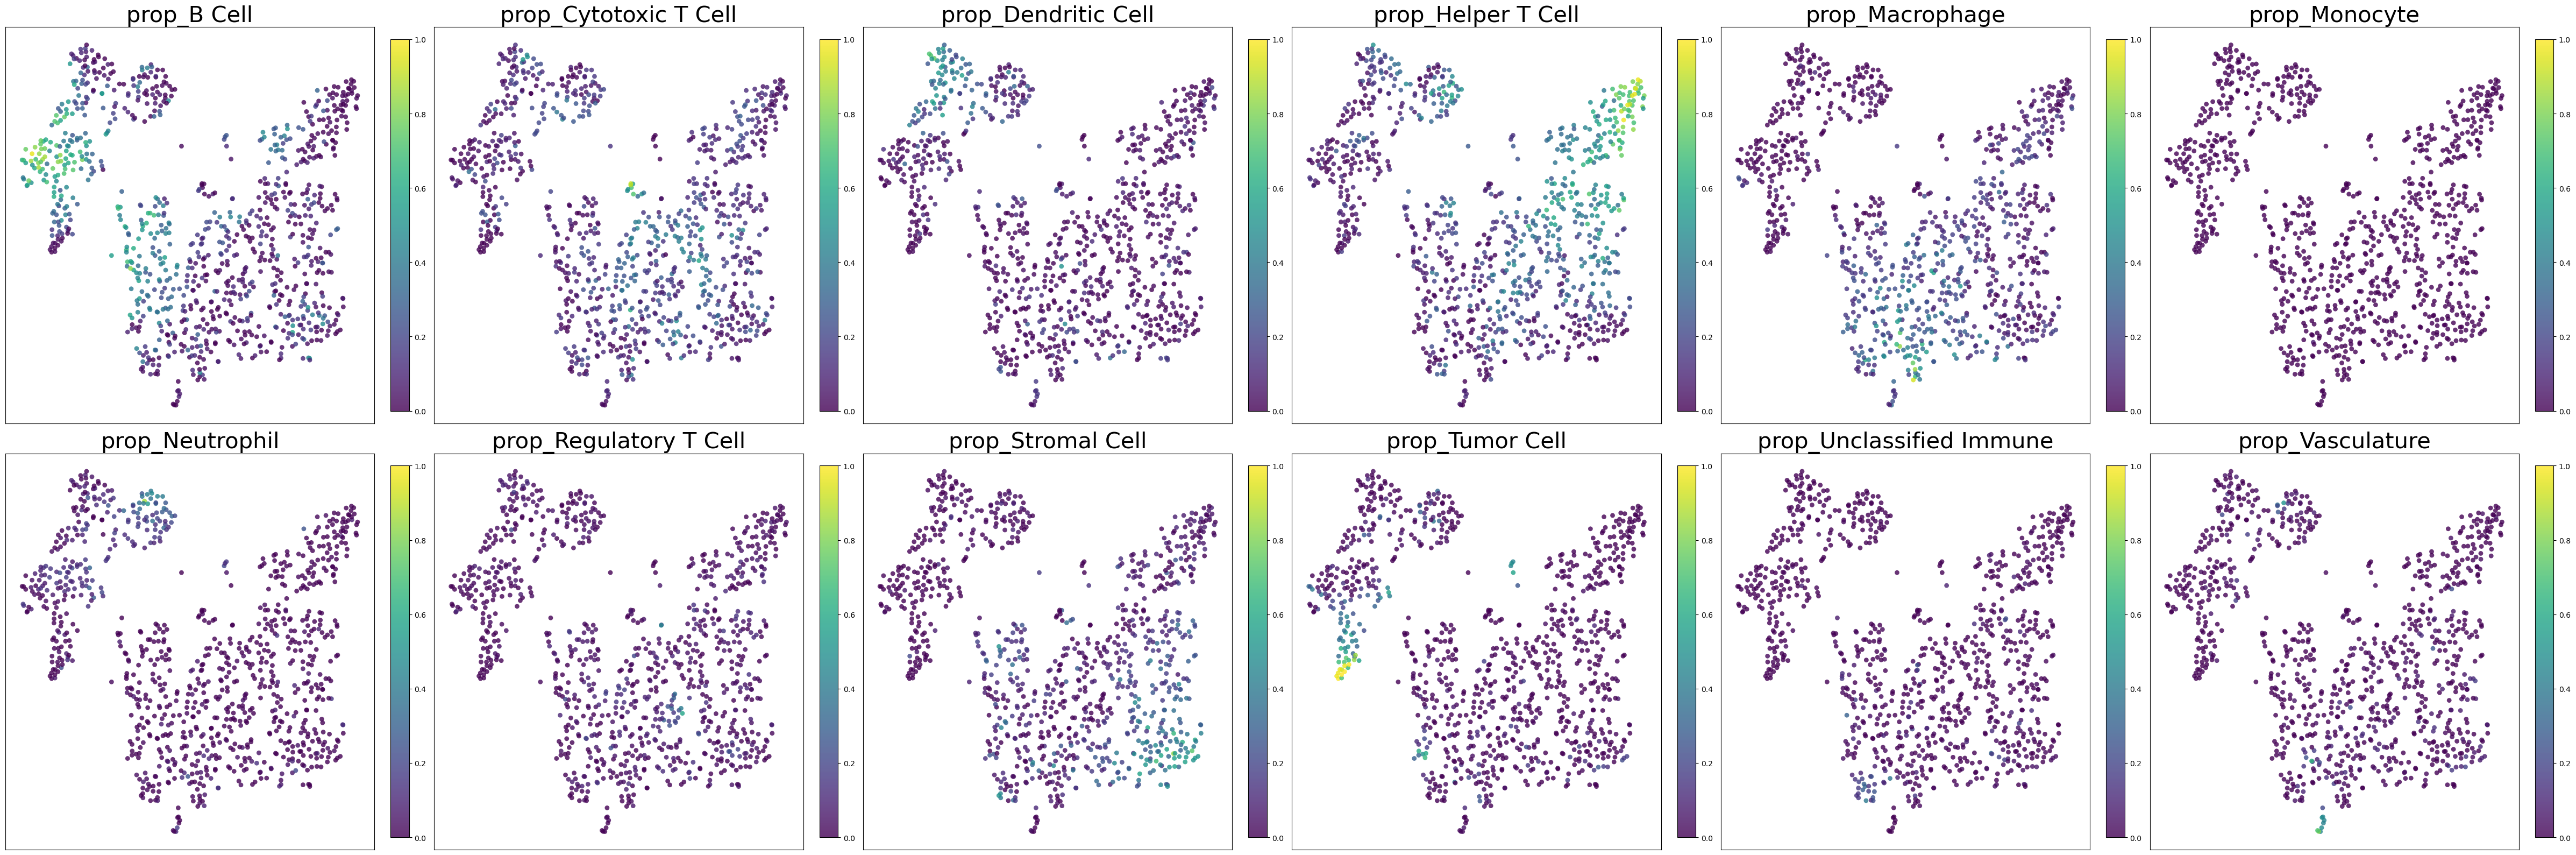

In [42]:
import numpy as np
import pandas as pd
import networkx as nx
from collections import Counter

# ---- prerequisites  ----
# G_all          : your big graph
# df_aligned     : aligned with G_all via align_df_with_G_all(...)
# anchors        : 1D array/list of node indices (into Z_nodes / df_aligned)
# roi_ids_anchor : roi_id per anchor
# patient_ids_anchor : patient_id per anchor
# cell_type_col : column name in df_aligned that contains the cell type

k = 4

cell_type_col = 'phenotype'
cell_types = df_aligned[cell_type_col].to_numpy()
unique_types = np.unique(cell_types)

# Map between graph nodes and row indices in df_aligned / Z_nodes
nodes_list = list(G_all.nodes())
node_to_idx = {node: i for i, node in enumerate(nodes_list)}

rows = []

for anchor_idx, roi_id, patient_id in zip(anchors, roi_ids_anchor, patient_ids_anchor):
    # 1) get the actual node corresponding to this anchor index
    center_node = nodes_list[anchor_idx]

    # 2) find all nodes within k hops (including the anchor itself)
    lengths = nx.single_source_shortest_path_length(G_all, center_node, cutoff=k)
    neigh_nodes = list(lengths.keys())

    # 3) convert neighborhood nodes -> indices -> cell types
    neigh_indices = [node_to_idx[n] for n in neigh_nodes]
    neigh_ct = cell_types[neigh_indices]

    # 4) count and convert to proportions
    counts = Counter(neigh_ct)
    total = len(neigh_indices)
    props = {f"prop_{ct}": counts.get(ct, 0) / total for ct in unique_types}

    # (optional) store some metadata for the anchor
    row = {
        "anchor_idx": anchor_idx,
        "roi_id": roi_id,
        "patient_id": patient_id,
        "n_neighbors_3hop": total,
    }
    row.update(props)
    rows.append(row)

# Final result: one row per anchor, proportions of each cell type in its 3-hop neighborhood
anchor_neighborhood_props = pd.DataFrame(rows)

print(anchor_neighborhood_props.head())

#################################Plot tsne
X_anchor = Z_nodes[anchors]

import numpy as np
import matplotlib.pyplot as plt
import math

# --- Collect proportion columns ---
prop_cols = [c for c in anchor_neighborhood_props.columns if c.startswith("prop_")]
K = len(prop_cols)

# --- Choose grid size ---
n_cols = 6
n_rows = math.ceil(K / n_cols)

# --- Global color range for consistency ---
vmin, vmax = 0.0, 1.0 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 8*n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for ax, col in zip(axes.flat, prop_cols):
    prop_vals = anchor_neighborhood_props[col].to_numpy()

    sc = ax.scatter(
        X2_anchor[:, 0],
        X2_anchor[:, 1],
        s=40,
        c=prop_vals,
        cmap="viridis",
        alpha=0.8,
        vmin=vmin,
        vmax=vmax,
        linewidths=0,
    )
    ax.set_title(col, fontsize=30)
    ax.set_xticks([])
    ax.set_yticks([])

    # individual colorbar
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# Hide unused axes (if K not filling grid)
for i in range(K, n_rows*n_cols):
    axes.flat[i].axis("off")

plt.tight_layout()
plt.show()


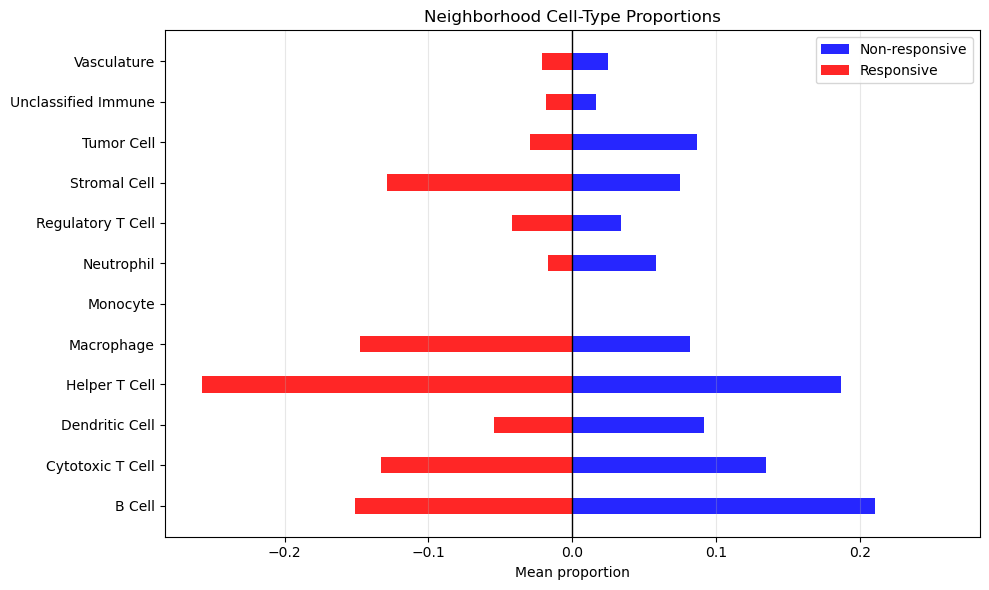

In [43]:
import numpy as np
import matplotlib.pyplot as plt



# ---- Collect proportion columns for each cell type ----
prop_cols = [c for c in anchor_neighborhood_props.columns if c.startswith("prop_")]
cell_type_names = [c.replace("prop_", "") for c in prop_cols]

means_0, stds_0 = [], []
means_1, stds_1 = [], []

for col in prop_cols:
    vals = anchor_neighborhood_props[col].to_numpy()

    vals_0 = vals[y_node_anchor == 0]
    vals_1 = vals[y_node_anchor == 1]

    means_0.append(vals_0.mean() if len(vals_0) else np.nan)
    stds_0.append(vals_0.std(ddof=1) if len(vals_0) > 1 else 0.0)

    means_1.append(vals_1.mean() if len(vals_1) else np.nan)
    stds_1.append(vals_1.std(ddof=1) if len(vals_1) > 1 else 0.0)

# Convert to numpy
means_0 = np.array(means_0)
stds_0 = np.array(stds_0)

# Class 1 goes LEFT (negative direction)
means_1 = -np.array(means_1)
stds_1 = np.array(stds_1)

# ---- Plot horizontal diverging bars ----
y = np.arange(len(prop_cols))  # each row = cell type

fig, ax = plt.subplots(figsize=(10, max(6, len(prop_cols)*0.4)))

# Class 0 → positive (right)
ax.barh(
    y,
    means_0,
    #xerr=stds_0,
    height=0.4,
    color="blue",
    alpha=0.85,
    label="Non-responsive",
)

# Class 1 → negative (left)
ax.barh(
    y,
    means_1,
    #xerr=stds_1,
    height=0.4,
    color="red",
    alpha=0.85,
    label="Responsive",
)

# Vertical zero line
ax.axvline(0, color="black", linewidth=1)

# Y-axis labels = cell types
ax.set_yticks(y)
ax.set_yticklabels(cell_type_names)

ax.set_xlabel("Mean proportion")
ax.set_title("Neighborhood Cell-Type Proportions")

# Symmetric x-limits for visual balance
max_val = max(means_0.max(), abs(means_1.min()))
ax.set_xlim(-1.1 * max_val, 1.1 * max_val)

ax.grid(axis="x", alpha=0.3)

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


## clustering of the embedding

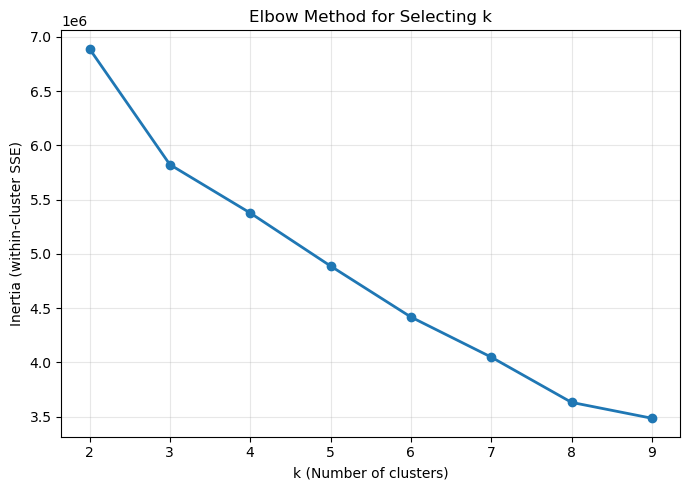

In [49]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# ---- Data ----
# X_anchor: (n_anchors × embedding_dim)

# ---- Range of k to test ----
K_range = range(2, 10)  
inertias = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_anchor)
    inertias.append(kmeans.inertia_)   # SSE / within-cluster sum of squares

# ---- Plot elbow curve ----
plt.figure(figsize=(7, 5))
plt.plot(K_range, inertias, marker='o', linewidth=2)
plt.xticks(list(K_range))
plt.xlabel("k (Number of clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method for Selecting k")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Cluster label distribution: [690 125 185]


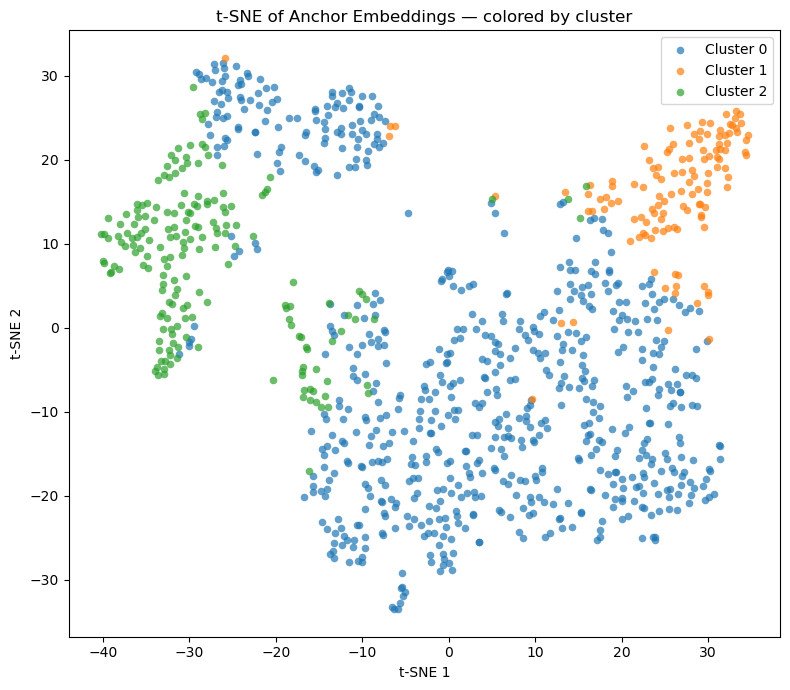

           B Cell  Cytotoxic T Cell  Dendritic Cell  Helper T Cell  \
cluster                                                              
0        0.123736          0.157728        0.078734       0.194794   
1        0.065098          0.103595        0.040361       0.585433   
2        0.472289          0.064675        0.072960       0.078741   

         Macrophage  Monocyte  Neutrophil  Regulatory T Cell  Stromal Cell  \
cluster                                                                      
0          0.144973  0.000111    0.038850           0.043333      0.127869   
1          0.071197  0.000000    0.013460           0.034089      0.066350   
2          0.030903  0.000000    0.050512           0.021012      0.028025   

         Tumor Cell  Unclassified Immune  Vasculature  
cluster                                                
0          0.038539             0.021517     0.029816  
1          0.005875             0.007867     0.006675  
2          0.165090             0.

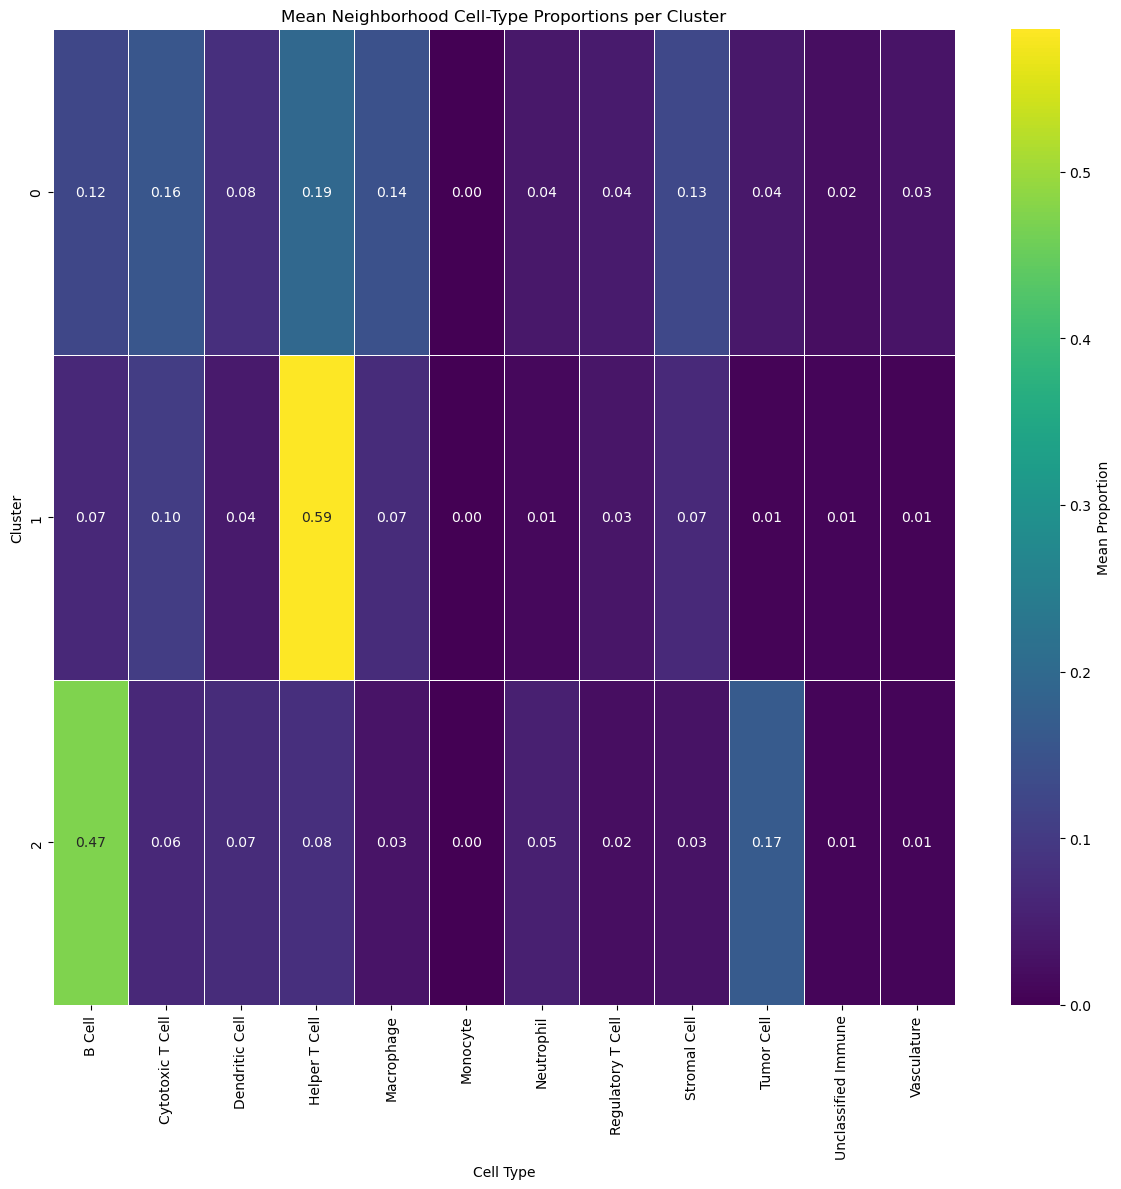

Cluster 0: representative anchor_idx=610758, dist=0.1137
Cluster 1: representative anchor_idx=651299, dist=0.0934
Cluster 2: representative anchor_idx=96748, dist=0.1096


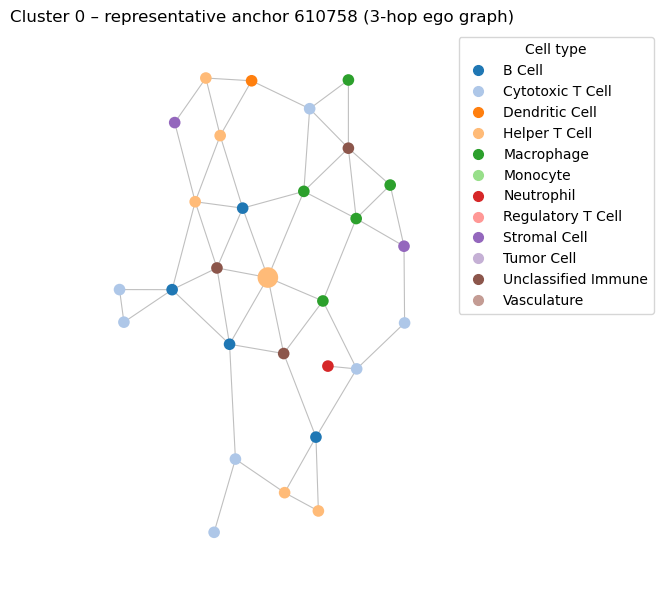

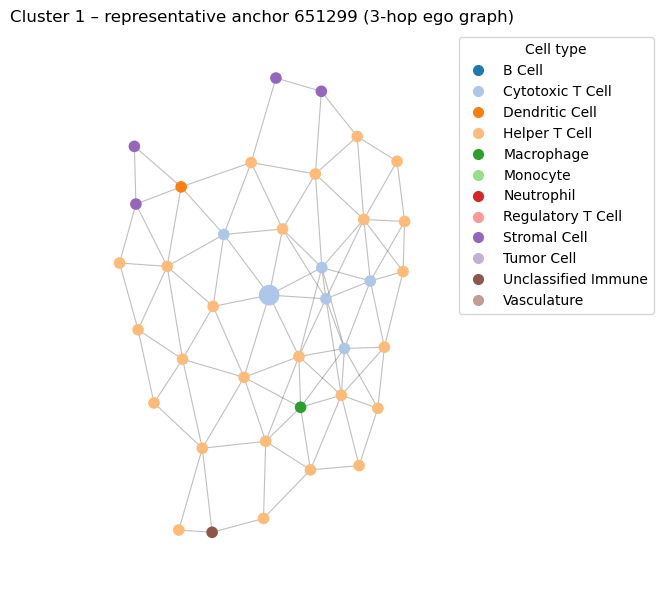

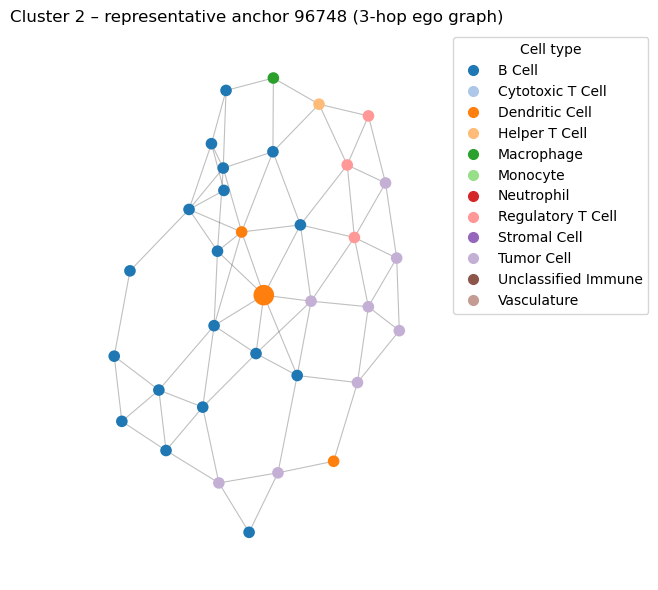

In [52]:

# ---- cluster embeddings ----
k = 3  # choose number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(X_anchor)

print("Cluster label distribution:", np.bincount(cluster_labels))
import matplotlib.pyplot as plt

unique_clusters = np.unique(cluster_labels)
colors = plt.cm.tab10.colors
cmap = {c: colors[c % len(colors)] for c in unique_clusters}

fig, ax = plt.subplots(figsize=(8, 7))

for c in unique_clusters:
    m = cluster_labels == c
    ax.scatter(
        X2_anchor[m, 0],
        X2_anchor[m, 1],
        s=30,
        alpha=0.7,
        color=cmap[c],
        label=f"Cluster {c}",
        linewidths=0
    )

ax.set_title("t-SNE of Anchor Embeddings — colored by cluster")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

'''Heatmap'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   # if seaborn is allowed

# --- Extract proportion columns ---
prop_cols = [c for c in anchor_neighborhood_props.columns if c.startswith("prop_")]

# Remove the "prop_" prefix for nicer labeling
pretty_names = [c.replace("prop_", "") for c in prop_cols]

# --- Build DataFrame with cluster labels included ---
df = anchor_neighborhood_props[prop_cols].copy()
df["cluster"] = cluster_labels

# --- Compute mean proportion per cluster ---
cluster_means = df.groupby("cluster")[prop_cols].mean()

# --- Replace column names for visualization ---
cluster_means.columns = pretty_names

print(cluster_means)

# --- Plot heatmap ---
plt.figure(figsize=(12, 6 + 0.5*len(prop_cols)))
sns.heatmap(
    cluster_means,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Mean Proportion"}
)

plt.title("Mean Neighborhood Cell-Type Proportions per Cluster")
plt.xlabel("Cell Type")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()




'''Representative prototypes'''
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

# ---- 1) Cell-type info and node index mapping ----
cell_type_col = 'phenotype'
cell_types = df_aligned[cell_type_col].to_numpy()
unique_types = np.unique(cell_types)

nodes_list = list(G_all.nodes())
node_to_idx = {node: i for i, node in enumerate(nodes_list)}

# fixed color map per cell type
type_to_color = {ct: plt.cm.tab20(i % 20) for i, ct in enumerate(unique_types)}

# ---- 2) Proportion matrix and representative anchor per cluster ----
prop_cols = [c for c in anchor_neighborhood_props.columns if c.startswith("prop_")]
prop_mat = anchor_neighborhood_props[prop_cols].to_numpy()

anchors_arr = np.asarray(anchors)
cluster_labels_arr = np.asarray(cluster_labels)

representative_anchors = {}   # cluster_id -> anchor_idx (index into nodes_list)

for c in np.unique(cluster_labels_arr):
    mask = (cluster_labels_arr == c)
    cluster_props = prop_mat[mask]

    if cluster_props.shape[0] == 0:
        continue

    cluster_mean = cluster_props.mean(axis=0)

    # L2 distance to cluster mean
    dists = np.linalg.norm(cluster_props - cluster_mean, axis=1)
    local_min = np.argmin(dists)

    rep_anchor_idx = anchors_arr[mask][local_min]  # this is a node index
    representative_anchors[c] = rep_anchor_idx

    print(f"Cluster {c}: representative anchor_idx={rep_anchor_idx}, dist={dists[local_min]:.4f}")

# ---- 3) Helper to plot 3-hop ego graph for one anchor ----
def plot_anchor_ego(anchor_idx, cluster_id=None, k=3):
    # center node in G_all
    center_node = nodes_list[anchor_idx]

    # nodes within k hops
    lengths = nx.single_source_shortest_path_length(G_all, center_node, cutoff=k)
    neigh_nodes = list(lengths.keys())

    # subgraph
    H = G_all.subgraph(neigh_nodes).copy()

    # layout
    pos = nx.spring_layout(H, seed=42)

    # node colors & sizes
    node_colors = []
    node_sizes = []
    for n in H.nodes():
        idx = node_to_idx[n]
        ct = cell_types[idx]
        node_colors.append(type_to_color.get(ct, "gray"))
        node_sizes.append(220 if n == center_node else 70)

    fig, ax = plt.subplots(figsize=(6, 6))
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.25, width=0.8)
    nx.draw_networkx_nodes(H, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           linewidths=0)

    # legend (cell types)
    handles = [
        Line2D([], [], marker='o', linestyle='None',
               color=type_to_color[ct], label=ct, markersize=7)
        for ct in unique_types
    ]
    ax.legend(handles=handles, title="Cell type",
              bbox_to_anchor=(1.05, 1.0), loc='upper left')

    title = f"Cluster {cluster_id} – representative anchor {anchor_idx} (3-hop ego graph)"
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# ---- 4) Plot representative 3-hop graph for each cluster ----
for c, anchor_idx in representative_anchors.items():
    plot_anchor_ego(anchor_idx, cluster_id=c, k=3)


Cluster 0: representative anchor_idx=610758, dist=0.1137
Cluster 1: representative anchor_idx=651299, dist=0.0934
Cluster 2: representative anchor_idx=96748, dist=0.1096


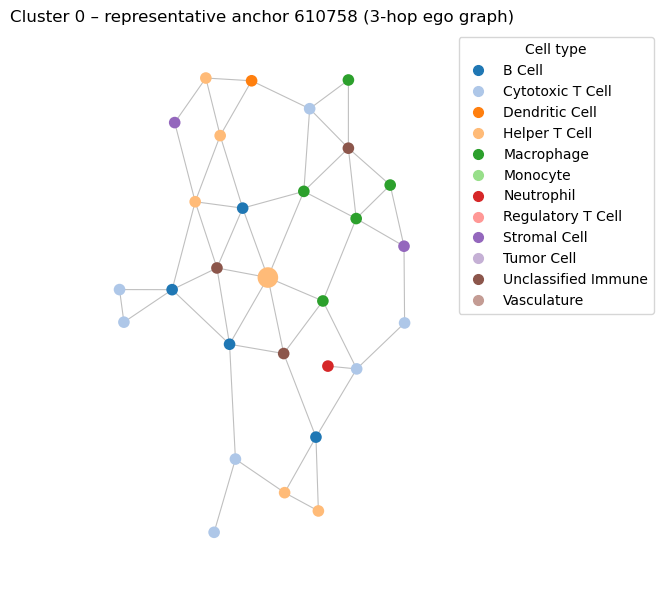

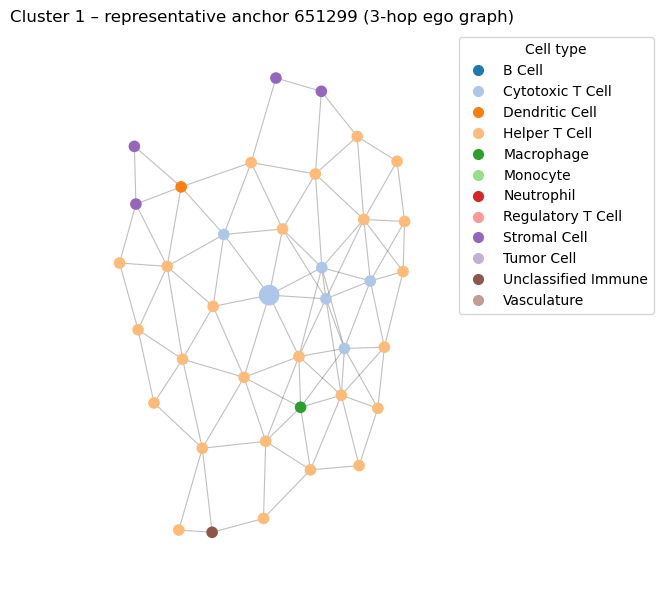

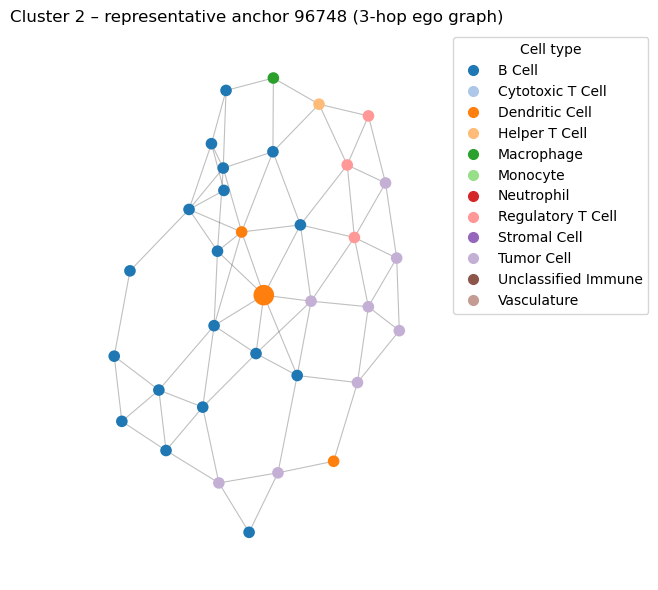

In [53]:
from scipy.sparse import csr_matrix, save_npz
'''Build ROI × motif sparse matrix '''
rows, cols, vals = [], [], []
for r_idx, roi in enumerate(roi_list):
    C = roi_to_counts.get(roi, {})
    total = sum(C.values()) if C else 1.0
    for t, c in C.items():
        rows.append(r_idx); cols.append(tok2idx[t]); vals.append(c/total)

X = csr_matrix((vals, (rows, cols)), shape=(len(roi_list), len(vocab)))
logging.info(f"Sparse matrix X: shape={X.shape}, nnz={X.nnz}")

# --- 6) Patient-grouped elastic-net logistic regression (discriminative motifs) ---
cv = StratifiedGroupKFold(n_splits=min(5, len(np.unique(groups))))
auc_list, acc_list = [], []

for tr, te in cv.split(X, y_roi, groups):
    clf = make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            class_weight="balanced", max_iter=5000, C=1.0, n_jobs=-1
        )
    )
    clf.fit(X[tr], y_roi[tr])
    proba = clf.predict_proba(X[te])[:, 1]
    auc_list.append(roc_auc_score(y_roi[te], proba))
    acc_list.append(accuracy_score(y_roi[te], (proba >= 0.5).astype(int)))

print(f"[Precomp-embed mining] Grouped CV  AUC={np.mean(auc_list):.3f}±{np.std(auc_list):.3f}  "
      f"ACC={np.mean(acc_list):.3f}±{np.std(acc_list):.3f}  "
      f"(anchors={len(anchors)}, ego_hops={ego_hops})")

final_clf = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5,
        class_weight="balanced", max_iter=8000, C=1.0, n_jobs=-1
    )
).fit(X, y_roi)

LR = final_clf.named_steps["logisticregression"]
coef = LR.coef_.ravel()
nz = np.where(coef != 0)[0]
order = nz[np.argsort(-np.abs(coef[nz]))]
topK = min(30, len(order))
top_df = pd.DataFrame({
    "motif_hash": [vocab[i] for i in order[:topK]],
    "coef": [float(coef[i]) for i in order[:topK]]
})
display(top_df)

outd = OUTDIR / "subgraph" / "fastrp_guided_mining"
outd.mkdir(parents=True, exist_ok=True)
save_npz(outd / "X_motifs.npz", X)
pd.DataFrame({"roi": roi_list, "y": y_roi, "group": groups}).to_csv(outd / "roi_meta.csv", index=False)
with open(outd / "vocab.json","w") as f: json.dump(vocab, f)
with open(outd / "tok2idx.json","w") as f: json.dump(tok2idx, f)
pd.DataFrame({"anchors_idx": anchors}).to_csv(outd / "anchors.csv", index=False)
import joblib
joblib.dump({"final_clf": final_clf}, outd / "model.pkl")
print("Saved to:", outd)

2025-11-12 13:43:06,439 | INFO | Sparse matrix X: shape=(219, 1000), nnz=1000
[Precomp-embed mining] Grouped CV  AUC=0.500±0.000  ACC=0.634±0.027  (anchors=1000, ego_hops=3)


,motif_hash,coef
0,ef183f7f10ce77e960890f92a2b7ea9014d5b1f4,0.228516
1,10567f750e486f617a65e812227f64a62d67a199,0.228450
2,bc2ca16008df561278de2a4ad49adbcec240efa4,0.228450
3,49acf33a303693e00d3d7d726f38c2e4ca292f3f,0.228449
4,f5457f15b27cb5a020a58385bab2e2e93550d795,0.228435
5,42e46131062e63a6dbcd9a6a0cdd87c3e7005663,0.228425
6,374155da7ac864a52235d1faf589d34531d6fc00,0.228420
7,6b8c6d086ae9c7e5b7a1f4a95ae71da0d46c1eee,0.228414
8,a112602be042500b966e6a702d37113bce477dfb,0.228386
9,f11e2528e2ef4858de76fedd9212a0cf00de0d3c,0.228364


Saved to: /projects/wangc/m344313/OVTMA_project/output/bms1_interface_radius_25_power/subgraph/fastrp_guided_mining


# Vis

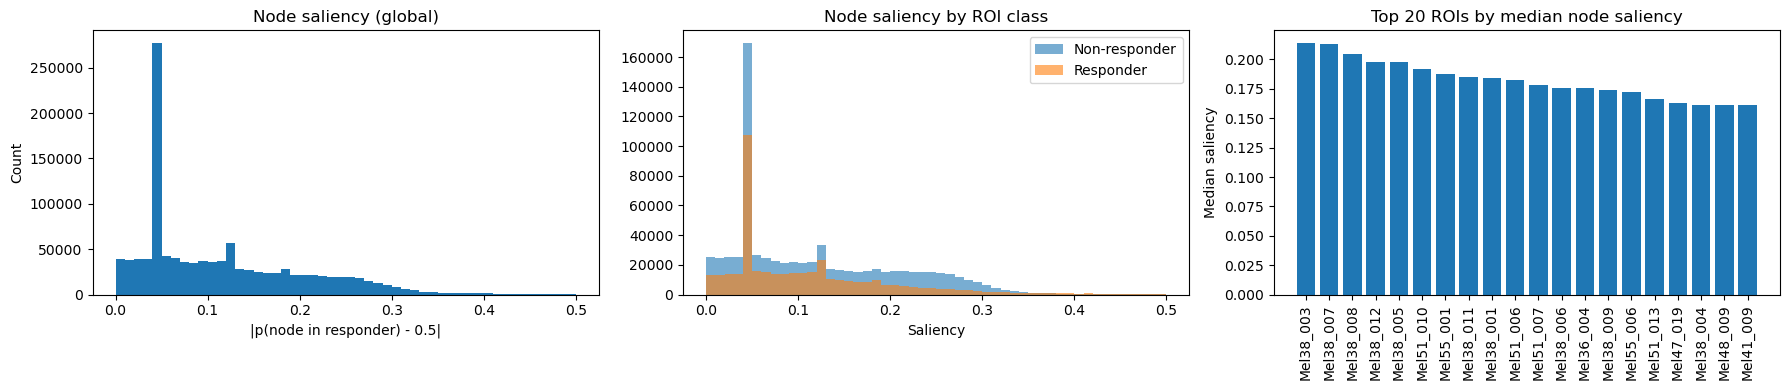

In [ ]:
'''Saliency overview (global + by class)'''

import numpy as np, matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

# 1) Global histogram
axs[0].hist(node_df["saliency"].values, bins=50)
axs[0].set_title("Node saliency (global)")
axs[0].set_xlabel("|p(node in responder) - 0.5|")
axs[0].set_ylabel("Count")

# 2) By ROI label (node inherits ROI label)
yn = node_df["roi"].map({r: y for r, y in zip(roi_list, y_roi)}).values
axs[1].hist(node_df["saliency"].values[yn==0], bins=50, alpha=0.6, label="Non-responder")
axs[1].hist(node_df["saliency"].values[yn==1], bins=50, alpha=0.6, label="Responder")
axs[1].set_title("Node saliency by ROI class")
axs[1].set_xlabel("Saliency")
axs[1].legend()

# 3) Per-ROI violin (top 20 ROIs by median saliency)
import pandas as pd
roi_sal = node_df.groupby("roi")["saliency"].median().sort_values(ascending=False).head(20)
axs[2].bar(range(len(roi_sal)), roi_sal.values)
axs[2].set_xticks(range(len(roi_sal)))
axs[2].set_xticklabels(roi_sal.index, rotation=90)
axs[2].set_title("Top 20 ROIs by median node saliency")
axs[2].set_ylabel("Median saliency")
plt.tight_layout()
plt.show()


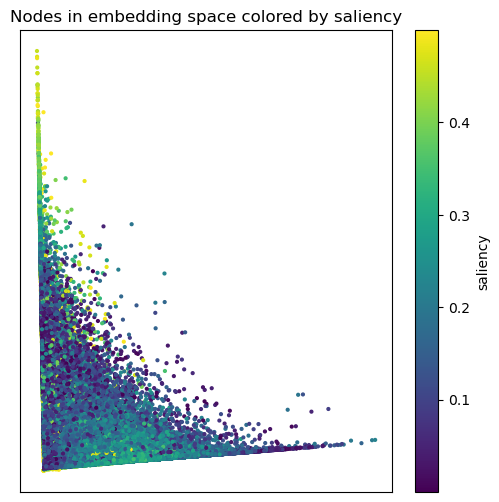

In [ ]:
'''2D projection of nodes colored by saliency (UMAP optional)'''

import numpy as np, matplotlib.pyplot as plt

# If you have UMAP installed, uncomment the next two lines:
# from umap import UMAP
# Z2 = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42).fit_transform(Z_nodes)

# Fallback: simple PCA to 2D
from sklearn.decomposition import PCA
Z2 = PCA(n_components=2, random_state=42).fit_transform(Z_nodes)

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(Z2[:,0], Z2[:,1], s=4, c=node_df["saliency"].values, cmap="viridis")
ax.set_title("Nodes in embedding space colored by saliency")
ax.set_xticks([]); ax.set_yticks([])
cbar = plt.colorbar(sc, ax=ax); cbar.set_label("saliency")
plt.show()


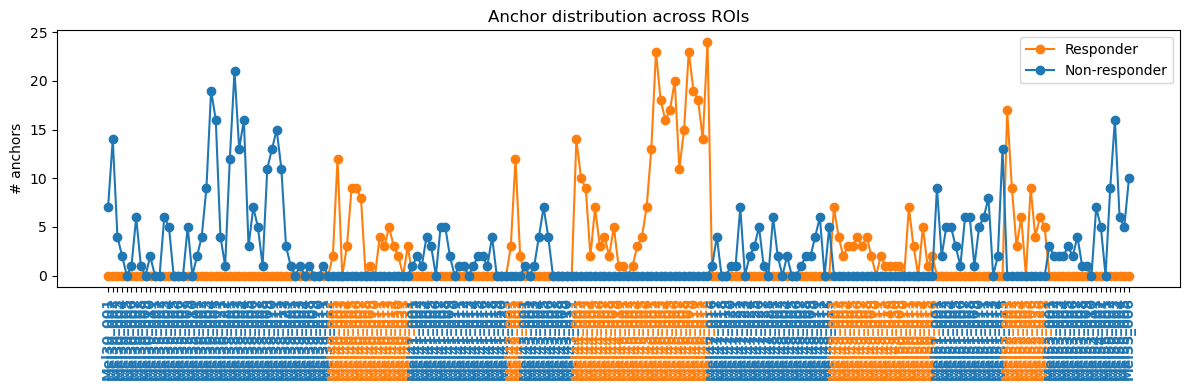

In [34]:
'''Where did anchors land? (per-class counts per ROI)'''

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- prepare anchor counts ---
a = node_df.iloc[anchors].copy()
a["class"] = a["roi"].map({r: y for r, y in zip(roi_list, y_roi)})

counts = (
    a.groupby(["roi", "class"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "nonresp_anchors", 1: "resp_anchors"})
)
# ensure same ROI order as roi_list
counts = counts.reindex(roi_list).fillna(0)

# --- plotting ---
fig, ax = plt.subplots(figsize=(12, 4))
palette = plt.cm.tab10.colors
colors = {"nonresp_anchors": palette[0], "resp_anchors": palette[1]}  # blue / orange

ax.plot(range(len(counts)), counts["resp_anchors"].values, marker="o",
        label="Responder", color=colors["resp_anchors"])
ax.plot(range(len(counts)), counts["nonresp_anchors"].values, marker="o",
        label="Non-responder", color=colors["nonresp_anchors"])

ax.set_ylabel("# anchors")
ax.set_title("Anchor distribution across ROIs")
ax.legend()

# --- color x-tick labels by ROI class ---
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=90)

# Determine each ROI’s class color (based on ROI label)
roi_class_colors = [
    colors["resp_anchors"] if roi_to_y.get(r, 0) == 1 else colors["nonresp_anchors"]
    for r in counts.index
]
for tick_label, c in zip(ax.get_xticklabels(), roi_class_colors):
    tick_label.set_color(c)
    tick_label.set_fontweight("bold")

plt.tight_layout()
plt.show()



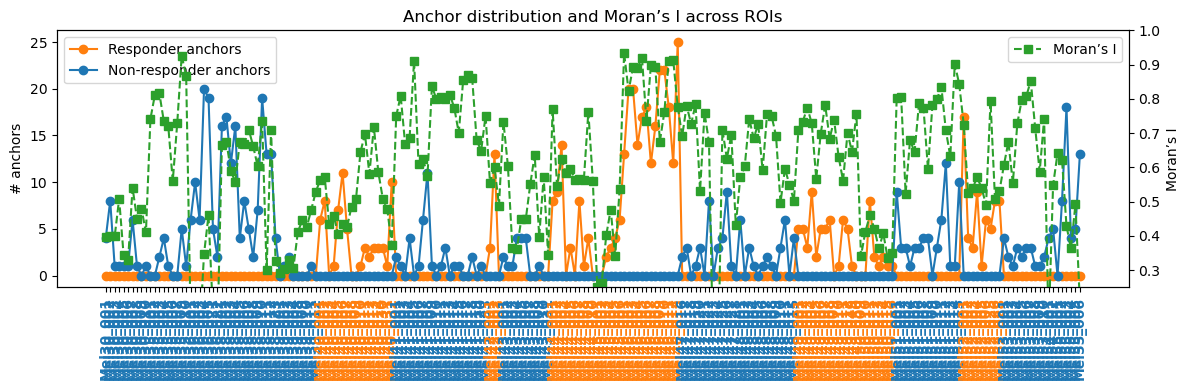

In [56]:
''' plot with Moran's I '''

# --- prepare anchor counts ---
a = node_df.iloc[anchors].copy()
a["class"] = a["roi"].map({r: y for r, y in zip(roi_list, y_roi)})

counts = (
    a.groupby(["roi", "class"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "nonresp_anchors", 1: "resp_anchors"})
)
# ensure same ROI order as roi_list
counts = counts.reindex(roi_list).fillna(0)


adj_moran = pd.read_csv('/people/m344313/TMA_Graph_Embedding/notebooks/bms1_moran_df.csv')
adj_moran
# reorder adj_moran['imageID'] to match counts.index
adj_moran = adj_moran.set_index('imageID').reindex(counts.index).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 4))
palette = plt.cm.tab10.colors
colors = {"nonresp_anchors": palette[0], "resp_anchors": palette[1]}
moran_color = palette[2]

# --- left y-axis: anchor counts ---
ax1.plot(range(len(counts)), counts["resp_anchors"].values, marker="o",
         label="Responder anchors", color=colors["resp_anchors"])
ax1.plot(range(len(counts)), counts["nonresp_anchors"].values, marker="o",
         label="Non-responder anchors", color=colors["nonresp_anchors"])
ax1.set_ylabel("# anchors")
ax1.legend(loc="upper left")

# --- right y-axis: Moran's I ---
ax2 = ax1.twinx()
y_moran = adj_moran["moran_I"].astype(float).values
ax2.plot(range(len(counts)), y_moran, marker="s", linestyle="--",
         label="Moran’s I", color=moran_color)
ax2.axhline(0.0, linestyle=":", linewidth=1, color="grey", alpha=0.7)
ax2.set_ylabel("Moran’s I")
ax2.set_ylim(0.25, 1)
ax2.legend(loc="upper right")

# --- x-ticks: same ROI order and colored by ROI class ---
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels(counts.index, rotation=90)
for tick_label, c in zip(ax1.get_xticklabels(), roi_class_colors):
    tick_label.set_color(c)
    tick_label.set_fontweight("bold")

ax1.set_title("Anchor distribution and Moran’s I across ROIs")
plt.tight_layout()
plt.show()


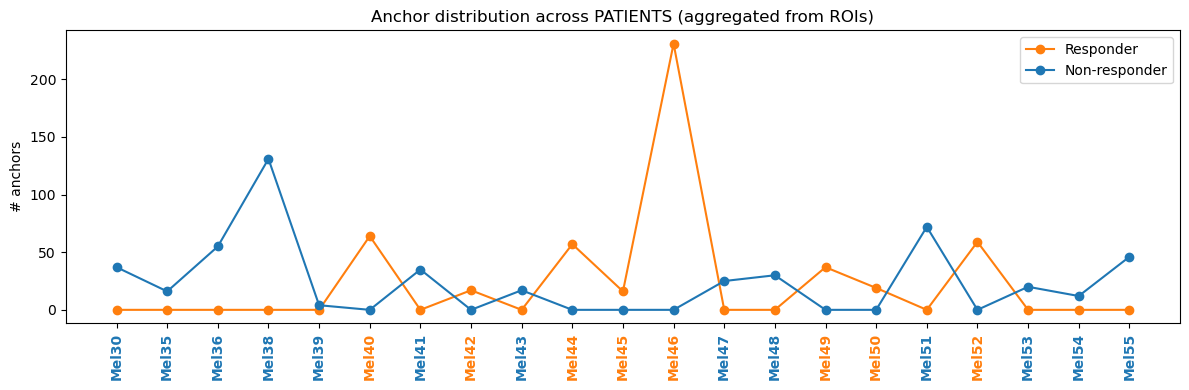

In [40]:
'''boxplot of number of anchors per patient'''
# === Anchor distribution aggregated by PATIENT (derived from ROI name prefix before '_') ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def _roi_to_patient(roi: str) -> str:
    s = str(roi)
    return s.split('_', 1)[0] if '_' in s else s

# --- prepare anchor counts at patient level ---
a = node_df.iloc[anchors].copy()
a["class"] = a["roi"].map({r: y for r, y in zip(roi_list, y_roi)})
a["patient"] = a["roi"].astype(str).map(_roi_to_patient)

# counts per patient × class
pt_counts = (
    a.groupby(["patient", "class"])
     .size()
     .unstack(fill_value=0)
     .rename(columns={0: "nonresp_anchors", 1: "resp_anchors"})
)

# determine patient label (majority vote across that patient's ROIs in our metadata)
roi_to_patient = pd.Series([_roi_to_patient(r) for r in roi_list], index=roi_list)
pt_label = (
    pd.DataFrame({"patient": roi_to_patient.values, "y": y_roi})
      .groupby("patient")["y"]
      .agg(lambda x: int(round(x.mean())))  # majority / ties -> round(0.5)=1
)

# reorder patients to a stable order (e.g., sorted by name or by total anchors)
# Here: sort by patient name
pt_counts = pt_counts.reindex(sorted(pt_counts.index))

# --- plotting ---
fig, ax = plt.subplots(figsize=(12, 4))
palette = plt.cm.tab10.colors
colors = {"nonresp_anchors": palette[0], "resp_anchors": palette[1]}  # blue / orange

x = np.arange(len(pt_counts))
ax.plot(x, pt_counts["resp_anchors"].values, marker="o",
        label="Responder", color=colors["resp_anchors"])
ax.plot(x, pt_counts["nonresp_anchors"].values, marker="o",
        label="Non-responder", color=colors["nonresp_anchors"])

ax.set_ylabel("# anchors")
ax.set_title("Anchor distribution across PATIENTS (aggregated from ROIs)")
ax.legend()

# --- color x-tick labels by PATIENT class ---
ax.set_xticks(x)
ax.set_xticklabels(pt_counts.index, rotation=90)

patient_colors = [
    colors["resp_anchors"] if pt_label.get(p, 0) == 1 else colors["nonresp_anchors"]
    for p in pt_counts.index
]
for tick_label, c in zip(ax.get_xticklabels(), patient_colors):
    tick_label.set_color(c)
    tick_label.set_fontweight("bold")

plt.tight_layout()
plt.show()


Prepared anchor/neighbor sets for 174 ROIs.


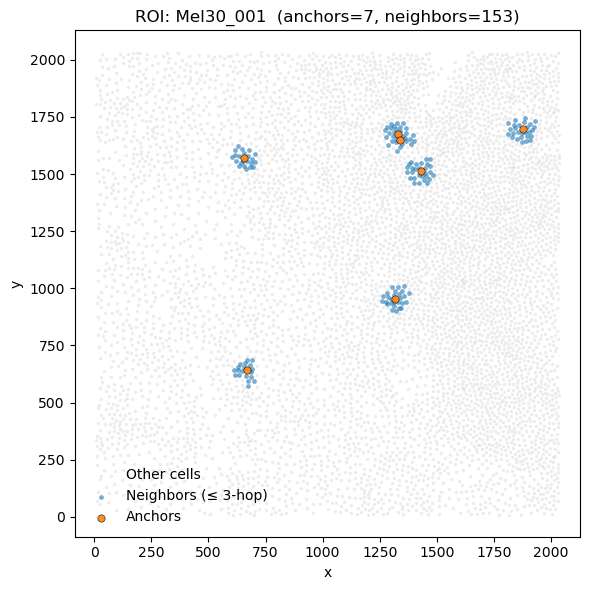

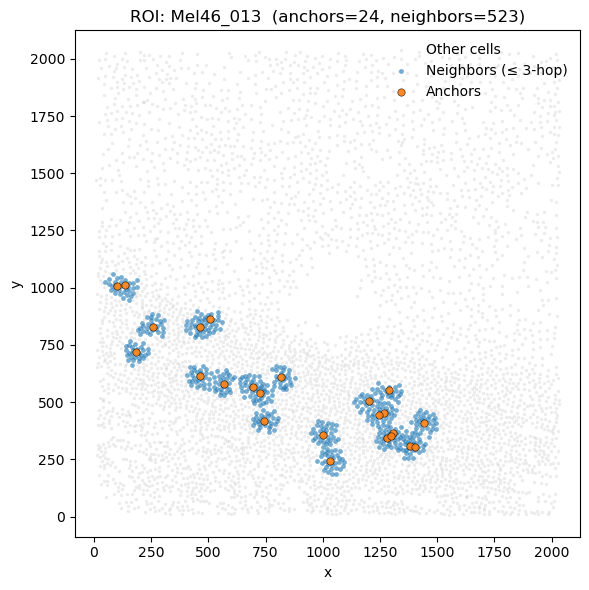

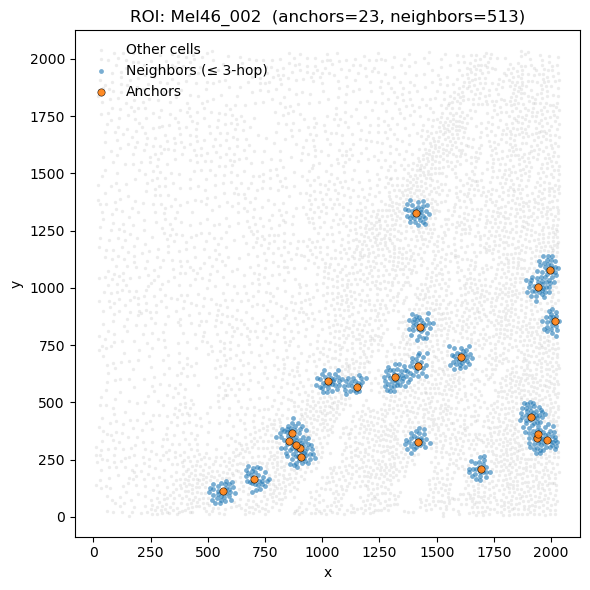

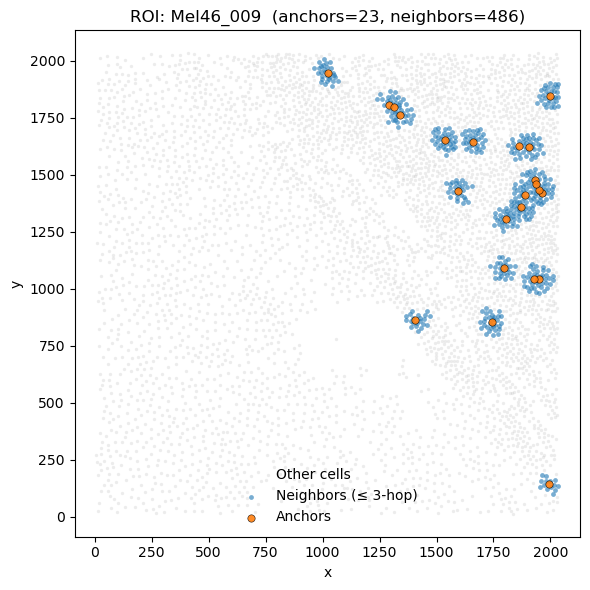

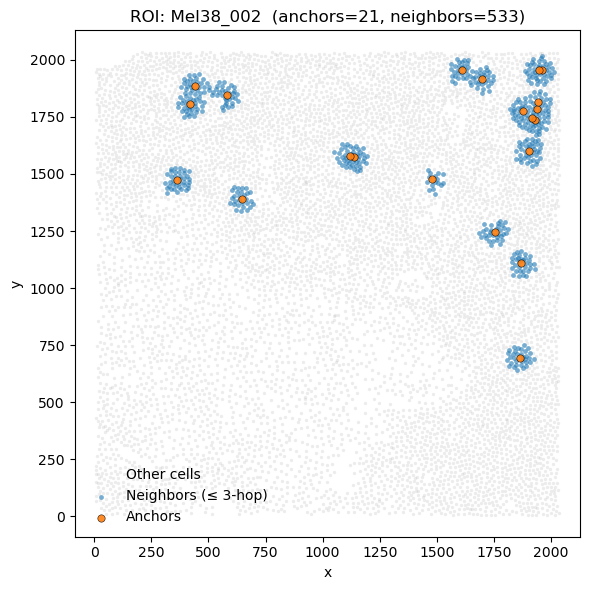

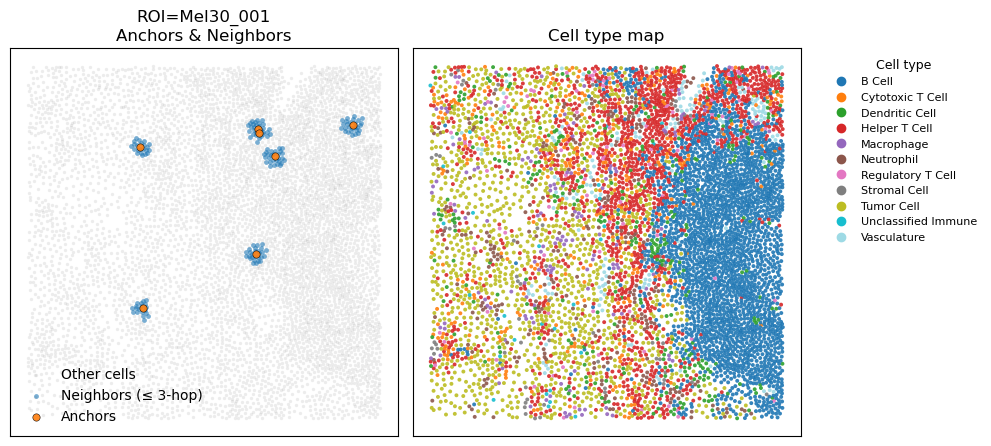

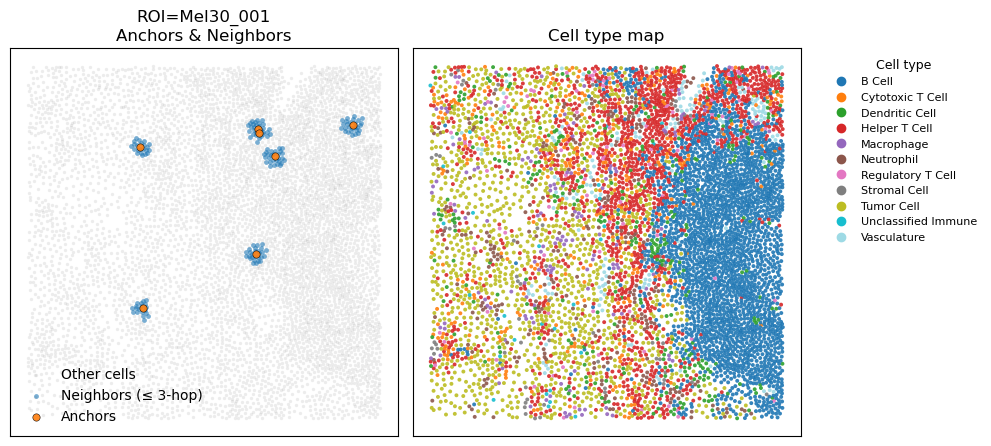

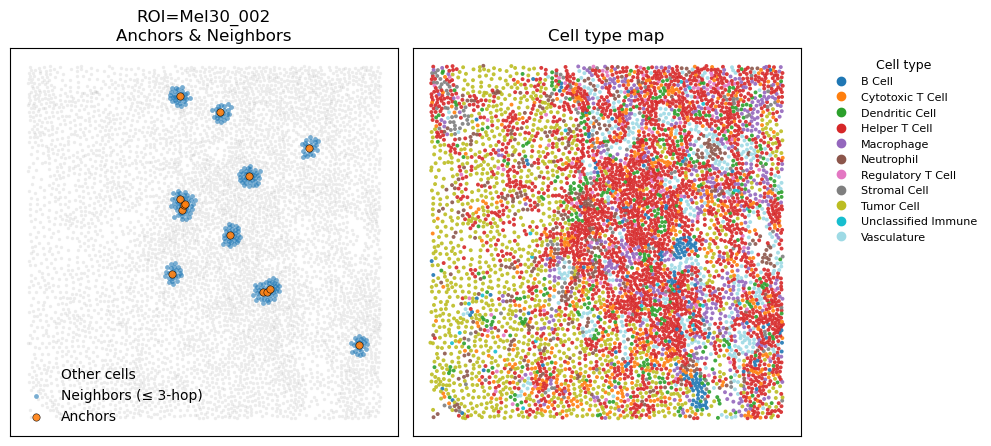

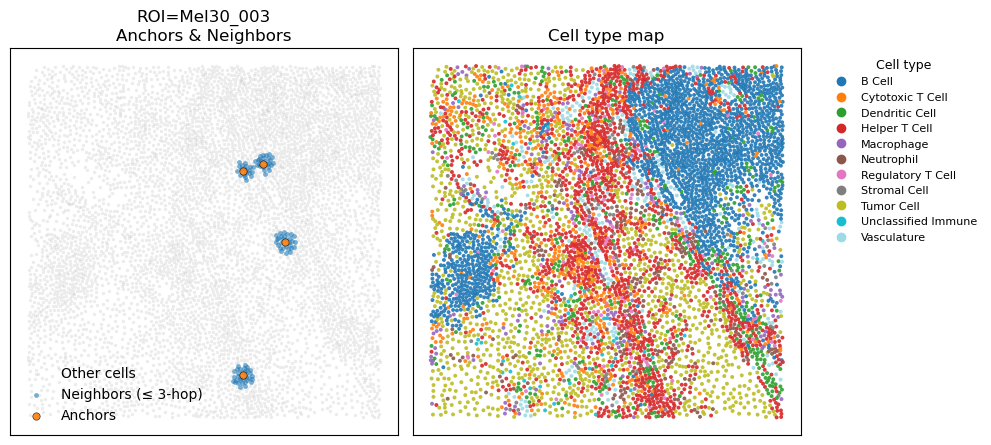

In [38]:
import numpy as np
import pandas as pd
import networkx as nx
from collections import defaultdict

# Build: ROI -> set(cell_id) for anchors and neighbors
roi_to_anchor_cells = defaultdict(set)
roi_to_neighbor_cells = defaultdict(set)

# convenience: node_df rows for anchors
a_df = node_df.iloc[anchors].copy()

for _, row in a_df.iterrows():
    ridx  = int(row["roi_idx"])
    roi   = roi_list[ridx]
    G     = graphs[ridx]
    center = int(row["cell_id"])
    if center not in G:
        continue
    roi_to_anchor_cells[roi].add(center)
    # neighbors within ego_hops
    H = nx.ego_graph(G, center, radius=ego_hops)
    roi_to_neighbor_cells[roi].update(H.nodes())

# ensure anchors are also in neighbor sets (for consistent masking)
for roi in roi_to_anchor_cells:
    roi_to_neighbor_cells[roi].update(roi_to_anchor_cells[roi])

print(f"Prepared anchor/neighbor sets for {len(roi_to_anchor_cells)} ROIs.")

import matplotlib.pyplot as plt
import numpy as np

def plot_roi_scatter_with_anchors(
    roi,
    df,
    roi_to_anchor_cells,
    roi_to_neighbor_cells,
    x_col="x", y_col="y", cell_col="cell_id", roi_col="roi_id",
    figsize=(6,6), alpha_all=0.15, s_all=6, s_neighbors=12, s_anchors=28
):
    """
    Scatter-plot all cells (light gray), highlight anchor neighbors (tab10[0], light blue),
    and anchors (tab10[1], orange) for a given ROI.
    """
    palette = plt.cm.tab10.colors
    c_all      = (0.5, 0.5, 0.5)     # light gray
    c_neighbors= palette[0]          # light blue
    c_anchors  = palette[1]          # orange

    sub = df[df[roi_col].astype(str) == str(roi)]
    if sub.empty:
        print(f"[warn] No rows for ROI={roi}")
        return

    # masks
    anchor_ids   = roi_to_anchor_cells.get(roi, set())
    neighbor_ids = roi_to_neighbor_cells.get(roi, set())

    is_anchor   = sub[cell_col].astype(int).isin(anchor_ids).values
    is_neighbor = sub[cell_col].astype(int).isin(neighbor_ids).values & (~is_anchor)

    # base (all others)
    is_other = ~(is_anchor | is_neighbor)

    fig, ax = plt.subplots(figsize=figsize)
    # plot order: others -> neighbors -> anchors (so anchors are on top)
    ax.scatter(sub.loc[is_other, x_col], sub.loc[is_other, y_col],
               s=s_all, c=[c_all], alpha=alpha_all, linewidths=0, rasterized=True, label="Other cells")
    ax.scatter(sub.loc[is_neighbor, x_col], sub.loc[is_neighbor, y_col],
               s=s_neighbors, c=[c_neighbors], alpha=0.6, linewidths=0, rasterized=True, label=f"Neighbors (≤ {ego_hops}-hop)")
    ax.scatter(sub.loc[is_anchor, x_col], sub.loc[is_anchor, y_col],
               s=s_anchors, c=[c_anchors], alpha=0.9, linewidths=0.4, edgecolors="k", label="Anchors")

    # aesthetics
    ax.set_title(f"ROI: {roi}  (anchors={int(is_anchor.sum())}, neighbors={int(is_neighbor.sum())})")
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(frameon=False, loc="best")
    plt.tight_layout()
    plt.show()


# --- Examples ---

# 1) Plot a single ROI by name
example_roi = roi_list[0]  # change to a specific ROI if you like
plot_roi_scatter_with_anchors(
    example_roi, df,
    roi_to_anchor_cells, roi_to_neighbor_cells,
    x_col="x", y_col="y", cell_col="cell_id", roi_col="roi_id",
    figsize=(6,6)
)

# 2) Plot top-K ROIs with most anchors
roi_by_anchor = sorted(roi_to_anchor_cells.keys(), key=lambda r: len(roi_to_anchor_cells[r]), reverse=True)
for roi in roi_by_anchor[:4]:  # top 4
    plot_roi_scatter_with_anchors(
        roi, df,
        roi_to_anchor_cells, roi_to_neighbor_cells,
        x_col="x", y_col="y", cell_col="cell_id", roi_col="roi_id",
        figsize=(6,6)
    )

import matplotlib.pyplot as plt
import numpy as np

def plot_roi_scatter_with_celltypes(
    roi,
    df,
    roi_to_anchor_cells,
    roi_to_neighbor_cells,
    x_col="x",
    y_col="y",
    cell_col="cell_id",
    type_col="phenotype",
    roi_col="roi_id",
    figsize=(10, 5),
    alpha_all=0.15,
    s_all=6,
    s_neighbors=12,
    s_anchors=28
):
    """
    Side-by-side plots for one ROI:
      Left: highlight anchors/neighbors/others.
      Right: color by cell type.
    """
    palette = plt.cm.tab10.colors
    c_all = (0.5, 0.5, 0.5)  # light gray
    c_neighbors = palette[0]  # light blue
    c_anchors = palette[1]    # orange

    sub = df[df[roi_col].astype(str) == str(roi)]
    if sub.empty:
        print(f"[warn] No rows for ROI={roi}")
        return

    # masks
    anchor_ids = roi_to_anchor_cells.get(roi, set())
    neighbor_ids = roi_to_neighbor_cells.get(roi, set())

    is_anchor = sub[cell_col].astype(int).isin(anchor_ids).values
    is_neighbor = sub[cell_col].astype(int).isin(neighbor_ids).values & (~is_anchor)
    is_other = ~(is_anchor | is_neighbor)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # --- Left panel: Anchors and neighbors ---
    ax = axes[0]
    ax.scatter(
        sub.loc[is_other, x_col],
        sub.loc[is_other, y_col],
        s=s_all,
        c=[c_all],
        alpha=alpha_all,
        linewidths=0,
        rasterized=True,
        label="Other cells",
    )
    ax.scatter(
        sub.loc[is_neighbor, x_col],
        sub.loc[is_neighbor, y_col],
        s=s_neighbors,
        c=[c_neighbors],
        alpha=0.6,
        linewidths=0,
        rasterized=True,
        label=f"Neighbors (≤ {ego_hops}-hop)",
    )
    ax.scatter(
        sub.loc[is_anchor, x_col],
        sub.loc[is_anchor, y_col],
        s=s_anchors,
        c=[c_anchors],
        alpha=0.9,
        linewidths=0.4,
        edgecolors="k",
        label="Anchors",
    )
    ax.set_title(f"ROI={roi}\nAnchors & Neighbors")
    ax.set_aspect("equal")
    ax.legend(frameon=False, loc="best")
    ax.set_xticks([])
    ax.set_yticks([])

    # --- Right panel: Cell type coloring ---
    ax2 = axes[1]
    types = sub[type_col].astype(str).values
    unique_types = sorted(set(types))
    colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(unique_types)))
    lut = {t: colors[i] for i, t in enumerate(unique_types)}
    node_colors = [lut[t] for t in types]

    sc = ax2.scatter(
        sub[x_col],
        sub[y_col],
        s=8,
        c=node_colors,
        alpha=0.9,
        linewidths=0,
        rasterized=True,
    )
    ax2.set_title("Cell type map")
    ax2.set_aspect("equal")
    ax2.set_xticks([])
    ax2.set_yticks([])

    # legend
    handles = [plt.Line2D([], [], color=lut[t], marker='o', linestyle='', markersize=6, label=t)
               for t in unique_types]
    ax2.legend(
        handles=handles,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False,
        fontsize=8,
        title="Cell type",
        title_fontsize=9,
    )

    plt.tight_layout()
    plt.show()


# --- Example usage ---
example_roi = roi_list[0]  # or any ROI of interest
plot_roi_scatter_with_celltypes(
    example_roi,
    df,
    roi_to_anchor_cells,
    roi_to_neighbor_cells,
    x_col="x",
    y_col="y",
    cell_col="cell_id",
    type_col="phenotype",
    roi_col="roi_id",
    figsize=(10, 5),
)

# Optional: loop over a few ROIs
for roi in roi_list[:3]:
    plot_roi_scatter_with_celltypes(roi, df, roi_to_anchor_cells, roi_to_neighbor_cells)



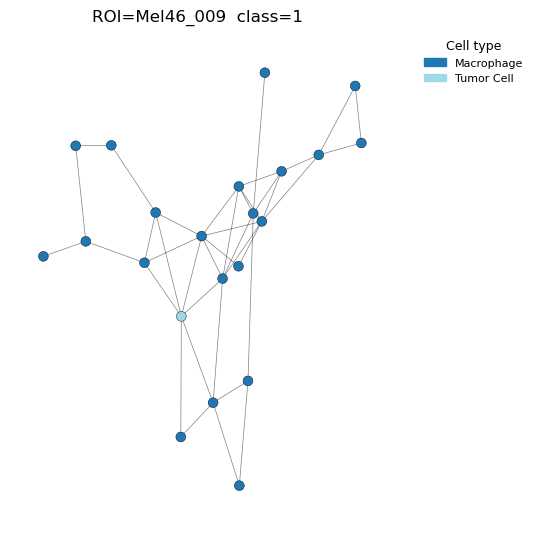

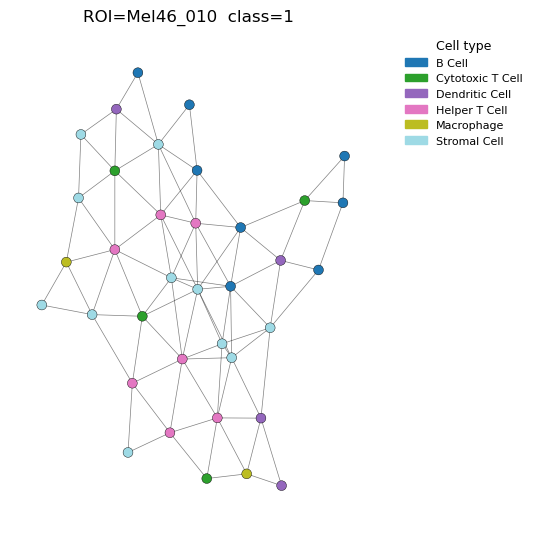

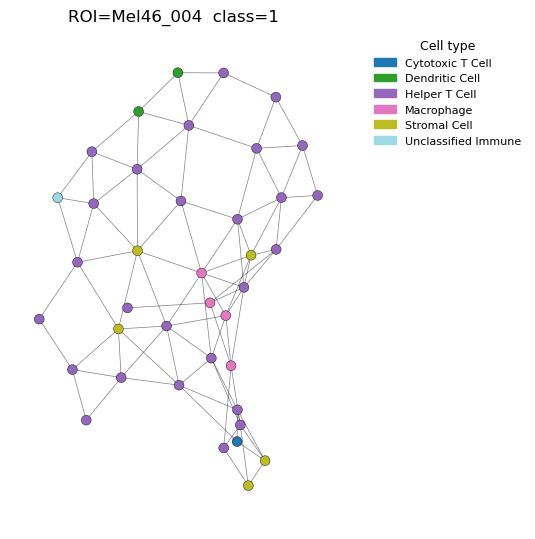

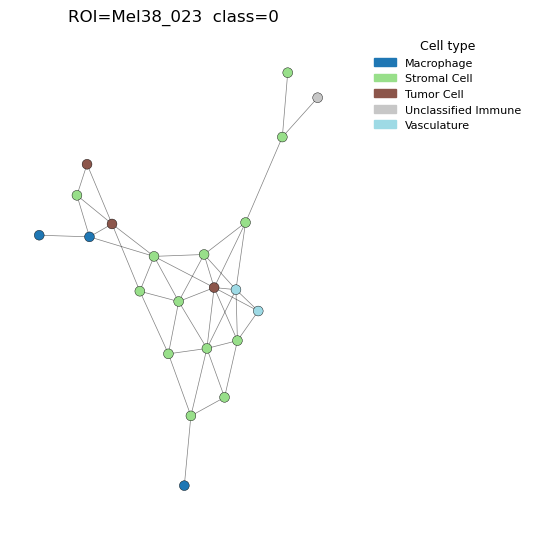

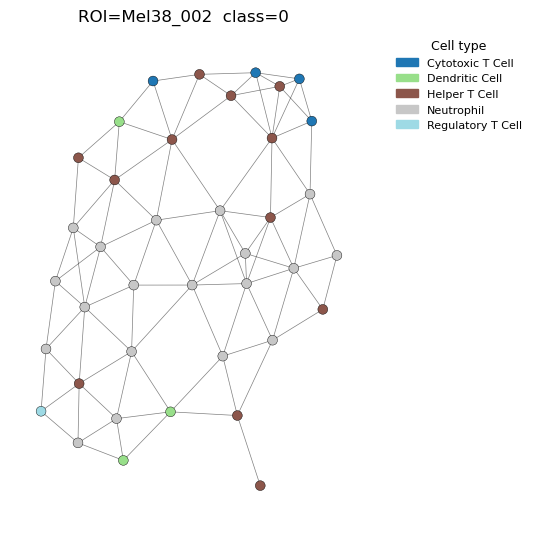

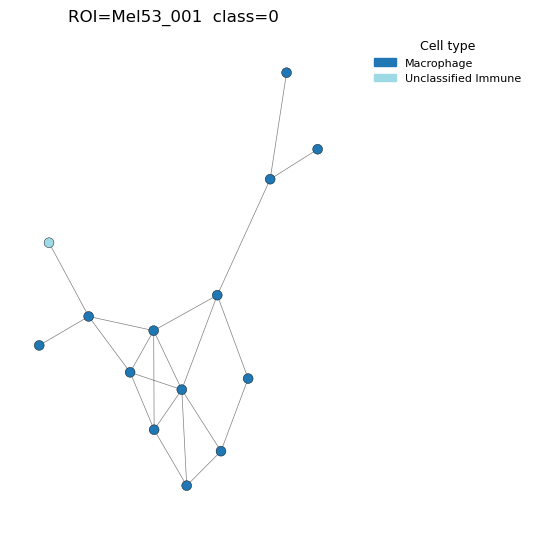

In [30]:
'''Visualize a few ego-subgraphs around top anchors'''
import networkx as nx, numpy as np, matplotlib.pyplot as plt, random, matplotlib.patches as mpatches

def draw_ego(G, center, hops=2, max_nodes=40, title=None):
    """
    Draw the ego-subgraph of node `center` up to `hops` hops, 
    color nodes by their 'label' (cell type), and show a legend.
    """
    H = nx.ego_graph(G, center, radius=hops)
    nodes = list(H.nodes())
    if len(nodes) > max_nodes:
        # keep the center and nearest neighbors by hop distance
        dists = dict(nx.single_source_shortest_path_length(G, center, cutoff=hops))
        nodes = [center] + [n for n in nodes if n != center]
        nodes = sorted(nodes, key=lambda n: dists.get(n, 99))[:max_nodes]
        H = G.subgraph(nodes).copy()

    # color by node 'label' (cell type)
    types = [H.nodes[n].get("label", "UNK") for n in H.nodes()]
    unique_types = sorted(set(types))
    lut = {t: i for i, t in enumerate(unique_types)}
    colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(unique_types)))
    node_colors = [colors[lut[t]] for t in types]

    # layout
    pos = nx.spring_layout(H, seed=0)
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    nx.draw_networkx_nodes(
        H, pos, node_size=50, node_color=node_colors, ax=ax, edgecolors="k", linewidths=0.3
    )
    nx.draw_networkx_edges(H, pos, width=0.5, alpha=0.5, ax=ax)

    ax.set_title(title or f"Ego {hops}-hop around {center} (|V|={H.number_of_nodes()})")
    ax.set_axis_off()

    # --- add legend for cell types ---
    patches = [mpatches.Patch(color=colors[lut[t]], label=t) for t in unique_types]
    legend = ax.legend(
        handles=patches,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False,
        title="Cell type",
        fontsize=8,
        title_fontsize=9,
    )
    plt.tight_layout()
    plt.show()


# Example: visualize top anchors from each class (same as before)
a = node_df.iloc[anchors].copy()
a["cls"] = a["roi"].map({r: y for r, y in zip(roi_list, y_roi)})
a = a.sort_values("saliency", ascending=False)

show_per_class = 3
for cls in [1, 0]:
    sub = a[a["cls"] == cls].head(show_per_class)
    for _, row in sub.iterrows():
        ridx = int(row["roi_idx"])
        roi = roi_list[ridx]
        G = graphs[ridx]
        center = int(row["cell_id"])
        draw_ego(
            G,
            center,
            hops=ego_hops,
            max_nodes=max_nodes_per_ego,
            title=f"ROI={roi}  class={cls}  "#saliency={row['saliency']:.3f}",
        )


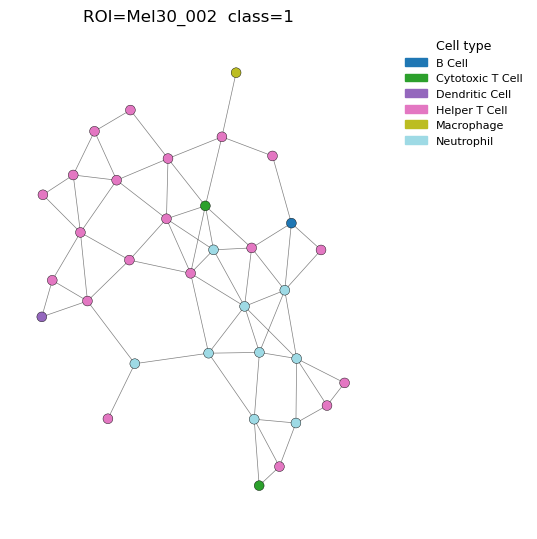

In [63]:
roi = 'Mel30_002'
ridx = a[a['roi'] == roi]['roi_idx'].values[0]
cell_id = a[a['roi'] == roi]['cell_id'].values[0]
G = graphs[ridx]
center = int(cell_id)
draw_ego(
    G,
    center,
    hops=ego_hops,
    max_nodes=max_nodes_per_ego,
    title=f"ROI={roi}  class={cls}  "#saliency={row['saliency']:.3f}",
)

In [62]:
a[a['roi'] == roi]['roi_idx']

6994     1
7748     1
8152     1
8409     1
8452     1
8709     1
9958     1
10925    1
Name: roi_idx, dtype: int64

In [57]:
sub

,roi_idx,roi,cell_id,saliency,p_node
1043561,200,Mel52_028,1106335,0.298807,0.201193
1043567,200,Mel52_028,1106341,0.303838,0.196162
1043684,200,Mel52_028,1106458,0.344936,0.844936
1043709,200,Mel52_028,1106483,0.361004,0.861004
1043717,200,Mel52_028,1106491,0.336418,0.836418
...,...,...,...,...,...
1049063,200,Mel52_028,1111837,0.308227,0.191773
1049064,200,Mel52_028,1111838,0.339397,0.160603
1049078,200,Mel52_028,1111852,0.313058,0.186942
1049101,200,Mel52_028,1111875,0.299228,0.200772


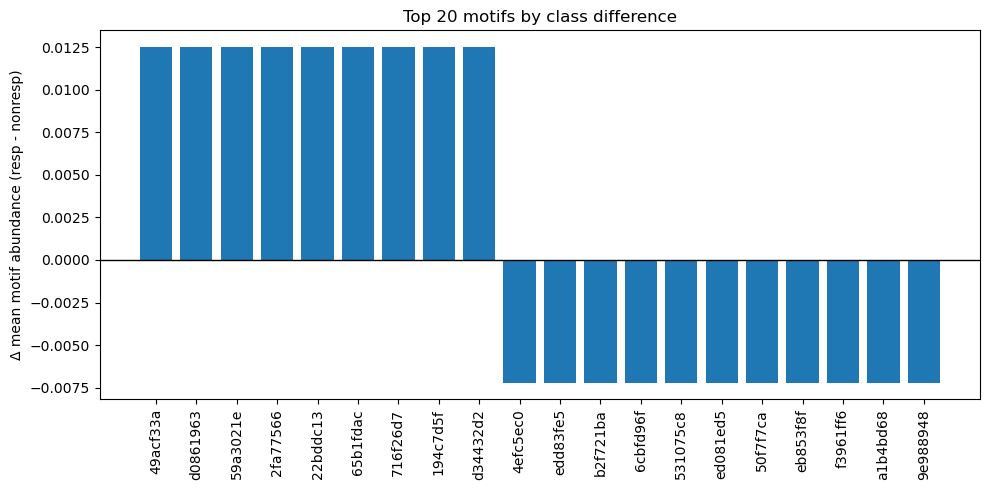

In [21]:
'''Motif burden vs. class (top motifs)'''
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

# Compute per-class average motif abundance
y_series = pd.Series(y_roi, index=roi_list, name="y")
X_df = pd.DataFrame.sparse.from_spmatrix(X, index=roi_list, columns=vocab)

avg0 = X_df[y_series==0].mean(axis=0).astype(float).values
avg1 = X_df[y_series==1].mean(axis=0).astype(float).values
delta = avg1 - avg0  # positive = enriched in responders

# Top motifs by absolute delta
top_idx = np.argsort(-np.abs(delta))[:20]
top_vocab = [vocab[i] for i in top_idx]
top_delta = delta[top_idx]

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(range(len(top_idx)), top_delta)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(top_idx)))
ax.set_xticklabels([v[:8] for v in top_vocab], rotation=90)  # show short hash prefix
ax.set_ylabel("Δ mean motif abundance (resp - nonresp)")
ax.set_title("Top 20 motifs by class difference")
plt.tight_layout(); plt.show()


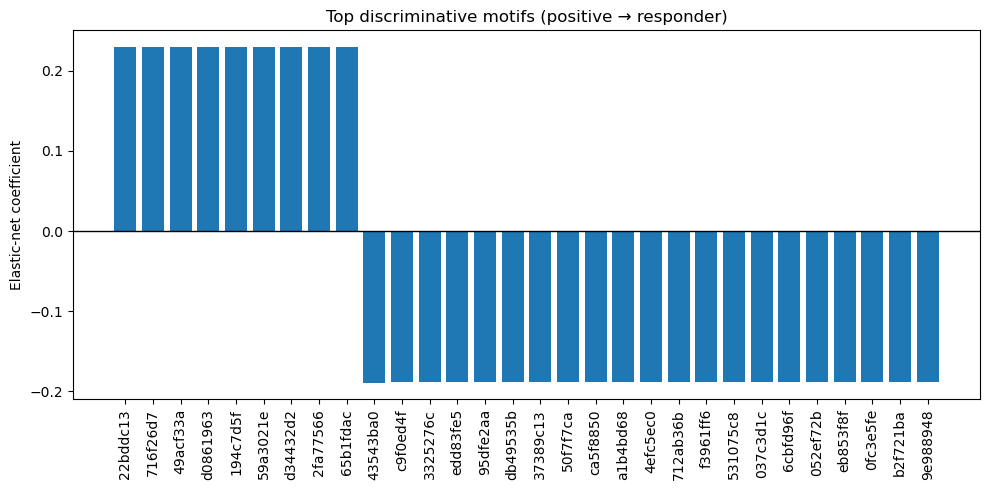

In [24]:
'''Model coefficients for discriminative motifs'''
import numpy as np, pandas as pd, matplotlib.pyplot as plt

LR = final_clf.named_steps["logisticregression"]
coef = LR.coef_.ravel()
nz = np.where(coef != 0)[0]
order = nz[np.argsort(-np.abs(coef[nz]))][:30]
motifs = [vocab[i] for i in order]
vals = coef[order]

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(range(len(vals)), vals)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels([m[:8] for m in motifs], rotation=90)
ax.set_ylabel("Elastic-net coefficient")
ax.set_title("Top discriminative motifs (positive → responder)")
plt.tight_layout(); plt.show()


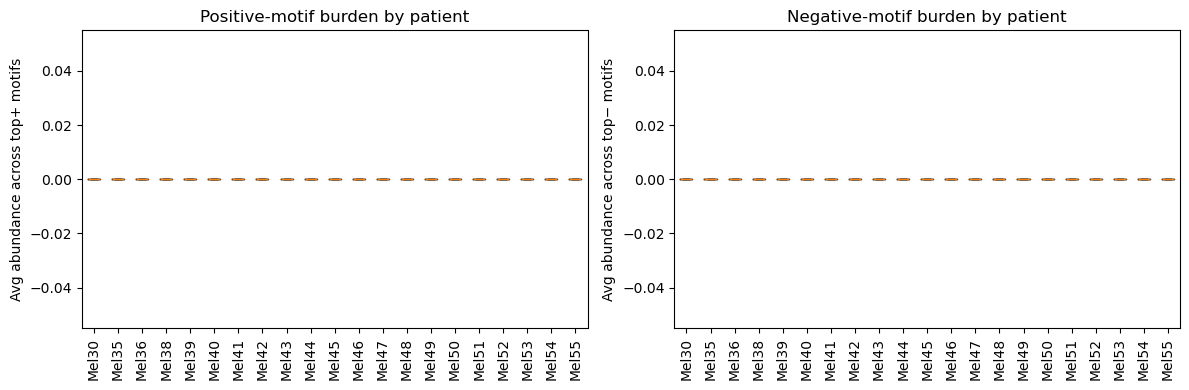

In [26]:
'''Per-patient motif burden (sanity check for patient-level effects)'''

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict

# pick top 5 positive and top 5 negative motifs
pos_ids = [i for i in order if coef[i] > 0][:5]
neg_ids = [i for i in order if coef[i] < 0][:5]

pos_burden = X[:, pos_ids].mean(axis=1).A.ravel() if len(pos_ids) else np.zeros(X.shape[0])
neg_burden = X[:, neg_ids].mean(axis=1).A.ravel() if len(neg_ids) else np.zeros(X.shape[0])

roi_meta_df = pd.DataFrame({"roi": roi_list, "y": y_roi, "patient": groups,
                            "pos_burden": pos_burden, "neg_burden": neg_burden})

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# positive motifs
box_data = [roi_meta_df.loc[roi_meta_df["patient"]==p, "pos_burden"].values
            for p in sorted(roi_meta_df["patient"].unique())]
axs[0].boxplot(box_data, showfliers=False)
axs[0].set_xticks(range(1, len(box_data)+1))
axs[0].set_xticklabels(sorted(roi_meta_df["patient"].unique()), rotation=90)
axs[0].set_title("Positive-motif burden by patient")
axs[0].set_ylabel("Avg abundance across top+ motifs")

# negative motifs
box_data = [roi_meta_df.loc[roi_meta_df["patient"]==p, "neg_burden"].values
            for p in sorted(roi_meta_df["patient"].unique())]
axs[1].boxplot(box_data, showfliers=False)
axs[1].set_xticks(range(1, len(box_data)+1))
axs[1].set_xticklabels(sorted(roi_meta_df["patient"].unique()), rotation=90)
axs[1].set_title("Negative-motif burden by patient")
axs[1].set_ylabel("Avg abundance across top− motifs")

plt.tight_layout(); plt.show()


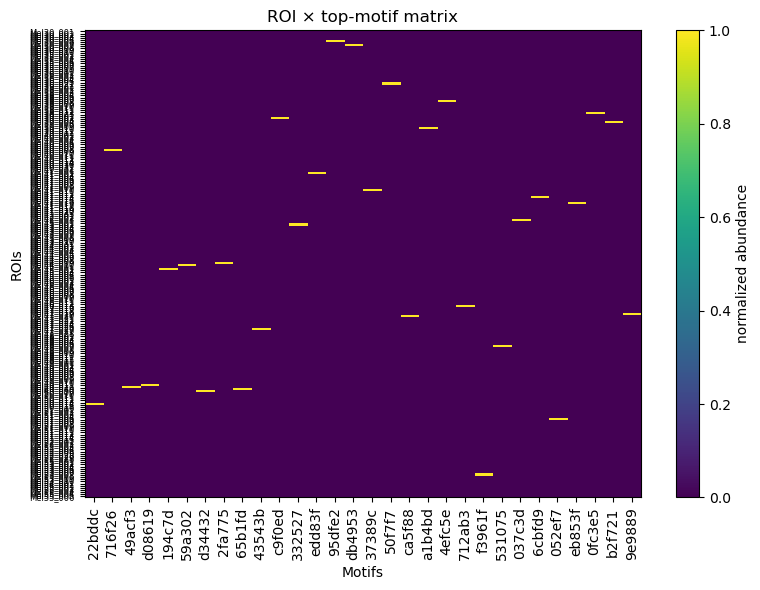

In [28]:
'''Quick ROI heatmap of motif loads (optionally cluster)'''
import numpy as np, matplotlib.pyplot as plt

# pick top 30 motifs by |coef|
sel = order[:30]
Xm = X[:, sel].toarray()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Xm, aspect="auto", interpolation="nearest")
ax.set_title("ROI × top-motif matrix")
ax.set_xlabel("Motifs"); ax.set_ylabel("ROIs")
ax.set_xticks(range(len(sel))); ax.set_xticklabels([vocab[i][:6] for i in sel], rotation=90)
ax.set_yticks(range(len(roi_list))); ax.set_yticklabels(roi_list, fontsize=6)
cbar = plt.colorbar(im, ax=ax); cbar.set_label("normalized abundance")
plt.tight_layout(); plt.show()
